Original

2025-04-10 23:31:40,869 - INFO - --- Starting Model Training ---
2025-04-10 23:31:41,066 - INFO - Successfully loaded 6000 records from C:/Users/tonyc/Desktop/dataset/finalgpt.json
2025-04-10 23:31:41,338 - INFO - Successfully loaded 6000 records from C:/Users/tonyc/Desktop/dataset/finalhuman.json
2025-04-10 23:31:41,338 - INFO - Extracting features for GPT data...
2025-04-10 23:31:43,926 - INFO - Processing record 500/6000 for feature extraction...
2025-04-10 23:31:45,221 - INFO - Processing record 1000/6000 for feature extraction...
2025-04-10 23:31:46,352 - INFO - Processing record 1500/6000 for feature extraction...
2025-04-10 23:31:47,324 - INFO - Processing record 2000/6000 for feature extraction...
2025-04-10 23:31:48,395 - INFO - Processing record 2500/6000 for feature extraction...
2025-04-10 23:31:49,587 - INFO - Processing record 3000/6000 for feature extraction...
2025-04-10 23:31:52,351 - INFO - Processing record 3500/6000 for feature extraction...
2025-04-10 23:31:58,212 

KeyboardInterrupt: 

2025-04-10 23:34:47,438 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-10 23:34:47,441 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-10 23:34:47,451 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-10 23:34:47,475 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-10 23:34:47,482 - INFO - Using categorical units to plot a list of strings that are all parsable as 

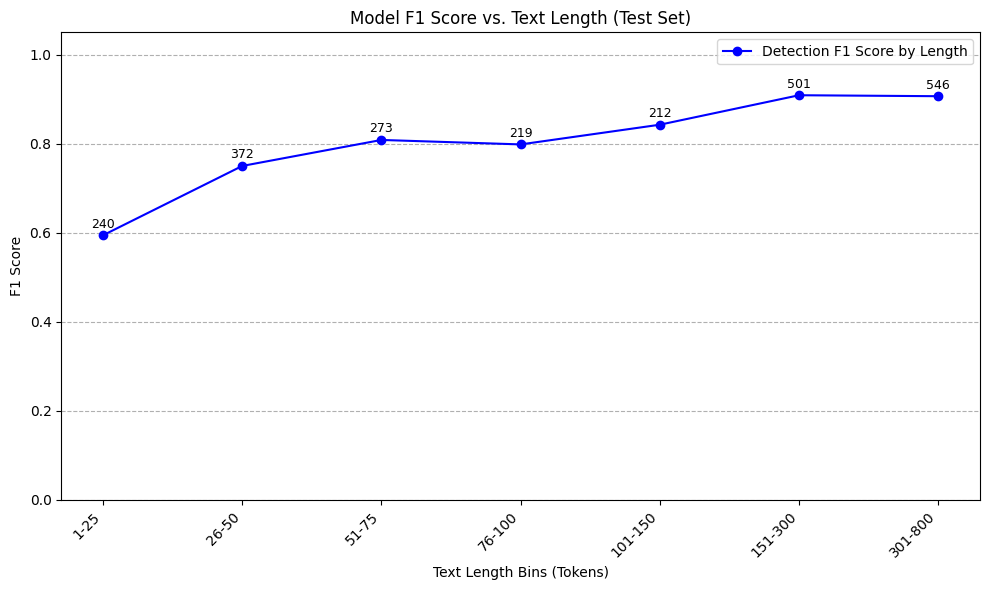

: 

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import xgboost as xgb
from sklearn.model_selection import train_test_split
import time
import pickle
import os
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, GPT2Tokenizer, GPT2LMHeadModel
import torch
import logging
import tkinter as tk
from tkinter import filedialog
from nltk.tokenize import sent_tokenize
from pdfminer.high_level import extract_text
import nltk
import shap

# --- Configuration & Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK 'punkt' tokenizer...")
    nltk.download('punkt')

# Global Feature Calculation Parameters
NGRAM_NUM = 5
CUTOFF_START = 4
CUTOFF_END = 800
FIXED_FEATURE_SIZE = 2 * NGRAM_NUM + 3

RESERVED_KEYS = {'input', 'common_features', 'avg_common_features',
                 'common_features_ori_vs_allcombined', 'fzwz_features', 'diff'}

T5_PROMPTS = [
    "Help me polish this",
    "Rewrite this for me",
    "Make this fluent while doing minimal change",
    "Refine this for me please, just show me the out put",
    "Concise this for me and keep all the information"
]
NUM_T5_REWRITES = len(T5_PROMPTS)

def _load_gpt2():
    try:
        logging.info("Loading GPT-2 model for perplexity (optional)...")
        tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        model = GPT2LMHeadModel.from_pretrained('gpt2')
        logging.info("GPT-2 model loaded.")
        return tokenizer, model
    except Exception as e:
        logging.warning(f"Could not load GPT-2 for perplexity calculation. Error: {e}")
        return None, None

def calculate_perplexity(text, tokenizer, model):
    if not tokenizer or not model:
        logging.warning("Tokenizer/model not available for perplexity calculation.")
        return 0.0
    if not text or not isinstance(text, str):
        return 0.0
    try:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=1024)
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs['input_ids'])
        loss = outputs.loss
        if loss is not None and loss.numel() == 1:
            return torch.exp(loss).item()
        else:
            return 0.0
    except Exception as e:
        logging.error(f"Error calculating perplexity: {e}")
        return 0.0

def tokenize_and_normalize(sentence):
    if not isinstance(sentence, str):
        return []
    return [word.lower().strip() for word in sentence.split() if word.strip()]

def extract_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_common_ngrams(tokens1, tokens2, max_n):
    common_counts = [0] * max_n
    for n in range(1, max_n + 1):
        ngrams1 = set(extract_ngrams(tokens1, n))
        if not ngrams1:
            continue
        ngrams2 = set(extract_ngrams(tokens2, n))
        common_counts[n-1] = len(ngrams1.intersection(ngrams2))
    return common_counts

def process_single_record(record):
    original_text = record.get('input', '')
    if not isinstance(original_text, str):
        original_text = str(original_text)
    original_tokens = tokenize_and_normalize(original_text)
    original_len = len(original_tokens)
    if original_len < CUTOFF_START or original_len > CUTOFF_END:
        return None
    rewrite_keys = [k for k in record if k not in RESERVED_KEYS]
    num_valid_rewrites = 0
    total_rewrite_len = 0
    all_common_ngram_counts = [0] * NGRAM_NUM
    fuzz_ratios = []
    token_set_ratios = []
    combined_rewrites_text = ''
    for key in rewrite_keys:
        rewrite_text = record.get(key, '')
        if not isinstance(rewrite_text, str):
            rewrite_text = str(rewrite_text)
        if rewrite_text:
            rewrite_tokens = tokenize_and_normalize(rewrite_text)
            combined_rewrites_text += (' ' + rewrite_text)
            num_valid_rewrites += 1
            total_rewrite_len += len(rewrite_tokens)
            common_counts = calculate_common_ngrams(original_tokens, rewrite_tokens, NGRAM_NUM)
            for i in range(NGRAM_NUM):
                all_common_ngram_counts[i] += common_counts[i]
            try:
                fuzz_ratios.append(fuzz.ratio(original_text, rewrite_text))
                token_set_ratios.append(fuzz.token_set_ratio(original_text, rewrite_text))
            except Exception as e:
                logging.warning(f"Fuzz ratio calculation failed for key '{key}'. Error: {e}")
                fuzz_ratios.append(0.0)
                token_set_ratios.append(0.0)
    processed = {'input': original_text, 'original_len': original_len}
    if num_valid_rewrites > 0:
        processed['avg_common_features'] = [count / num_valid_rewrites for count in all_common_ngram_counts]
        processed['avg_len_diff'] = (total_rewrite_len / num_valid_rewrites) - original_len
        processed['avg_fuzz_ratio'] = np.mean(fuzz_ratios) if fuzz_ratios else 0.0
        processed['avg_token_set_ratio'] = np.mean(token_set_ratios) if token_set_ratios else 0.0
    else:
        processed['avg_common_features'] = [0.0] * NGRAM_NUM
        processed['avg_len_diff'] = -original_len
        processed['avg_fuzz_ratio'] = 0.0
        processed['avg_token_set_ratio'] = 0.0
    combined_tokens = tokenize_and_normalize(combined_rewrites_text.strip())
    processed['common_ori_vs_combined'] = calculate_common_ngrams(original_tokens, combined_tokens, NGRAM_NUM)
    return processed

def extract_feature_vector(processed_record, fixed_size=FIXED_FEATURE_SIZE):
    if processed_record is None:
        return None
    original_len = processed_record.get('original_len', 0)
    norm_factor = float(max(1, original_len))
    features = []
    avg_common = processed_record.get('avg_common_features', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in avg_common[:NGRAM_NUM]])
    ori_vs_combined = processed_record.get('common_ori_vs_combined', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in ori_vs_combined[:NGRAM_NUM]])
    features.append(processed_record.get('avg_fuzz_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_token_set_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_len_diff', 0.0) / norm_factor)
    current_len = len(features)
    if current_len < fixed_size:
        features.extend([0.0] * (fixed_size - current_len))
    elif current_len > fixed_size:
        logging.warning(f"Feature vector size ({current_len}) > fixed size ({fixed_size}). Truncating.")
        features = features[:fixed_size]
    if len(features) != fixed_size:
        logging.error(f"Final feature vector size mismatch: {len(features)} != {fixed_size}. Returning None.")
        return None
    return np.array(features)

def prepare_features_for_dataset(raw_data_list):
    all_features = []
    original_lengths = []
    for i, record in enumerate(raw_data_list):
        if (i + 1) % 500 == 0:
            logging.info(f"Processing record {i+1}/{len(raw_data_list)} for feature extraction...")
        processed = process_single_record(record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                original_lengths.append(processed['original_len'])
    if not all_features:
        logging.warning("No features extracted. Returning empty arrays.")
        return np.empty((0, FIXED_FEATURE_SIZE)), np.array([])
    return np.vstack(all_features), np.array(original_lengths)

def train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths):
    if gpt_features.shape[0] == 0 or human_features.shape[0] == 0:
        logging.error("Cannot train model: One or both feature sets are empty.")
        return None
    logging.info(f"Training data shapes: GPT={gpt_features.shape}, Human={human_features.shape}")
    X = np.concatenate((gpt_features, human_features), axis=0)
    y = np.concatenate((np.ones(gpt_features.shape[0]), np.zeros(human_features.shape[0])), axis=0)
    lengths = np.concatenate((gpt_lengths, human_lengths), axis=0)
    min_samples_per_class = 10
    test_size = 0.2
    if gpt_features.shape[0] < min_samples_per_class or human_features.shape[0] < min_samples_per_class or (gpt_features.shape[0] + human_features.shape[0]) * test_size < 2:
        logging.warning("Not enough samples for train/test split. Training on all data.")
        X_train, y_train = X, y
        X_test, y_test, len_test = None, None, None
    else:
        try:
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=test_size, random_state=42, stratify=y
            )
            logging.info(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
        except ValueError:
            logging.warning("Stratified split failed. Falling back to non-stratified.")
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=test_size, random_state=42
            )
            logging.info(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
    logging.info("Training XGBoost classifier...")
    clf = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
    clf.fit(X_train, y_train)
    logging.info("Training complete.")
    if X_test is not None and y_test is not None and len(y_test) > 0:
        logging.info("Evaluating classifier on test data...")
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0.0)
        brier = brier_score_loss(y_test, y_prob[:, 1])
        confidence = np.mean(np.max(y_prob, axis=1))
        logging.info("--- Overall Test Metrics ---")
        logging.info(f" Accuracy: {accuracy:.4f}")
        logging.info(f" F1 Score: {f1:.4f}")
        logging.info(f" Brier Score (MSE): {brier:.4f}")
        logging.info(f" Average Confidence: {confidence:.4f}")
        logging.info("----------------------------")
        plot_length_ablation(y_test, y_pred, len_test, "len_ablation_f1.png")
    return clf

def plot_length_ablation(y_true, y_pred, lengths, filename="length_ablation.png"):
    logging.info("Performing length ablation study...")
    length_bins = [(0, 25), (25, 50), (50, 75), (75, 100), (100, 150), (150, 300), (300, CUTOFF_END)]
    f1_scores = []
    bin_labels = []
    bin_counts = []
    for start, finish in length_bins:
        mask = (lengths > start) & (lengths <= finish)
        if np.sum(mask) > 0:
            sub_y_true = y_true[mask]
            sub_y_pred = y_pred[mask]
            sub_f1 = f1_score(sub_y_true, sub_y_pred, zero_division=0.0)
            count = len(sub_y_true)
            label = f"{start+1}-{finish}"
            f1_scores.append(sub_f1)
            bin_labels.append(label)
            bin_counts.append(count)
            logging.info(f" Length {label}: F1={sub_f1:.4f}, Samples={count}")
        else:
            logging.info(f" Length {start+1}-{finish}: No samples in this bin.")
    if bin_labels and f1_scores:
        plt.figure(figsize=(10, 6))
        plt.plot(bin_labels, f1_scores, '-o', color='blue', label='Detection F1 Score by Length')
        for i, count in enumerate(bin_counts):
            if count > 0:
                plt.text(bin_labels[i], f1_scores[i] + 0.01, str(count), fontsize=9, ha='center', va='bottom')
        plt.title('Model F1 Score vs. Text Length (Test Set)')
        plt.xlabel('Text Length Bins (Tokens)')
        plt.ylabel('F1 Score')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True, axis='y', linestyle='--')
        plt.tight_layout()
        try:
            plt.savefig(filename)
            logging.info(f"Saved length ablation plot to {filename}")
        except Exception as e:
            logging.warning(f"Could not save plot '{filename}'. Error: {e}")
    else:
        logging.info("No data available for length ablation plot.")

def load_t5_model(model_name='t5-small'):
    try:
        logging.info(f"Loading T5 model ({model_name}) and tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model.to(device)
        logging.info(f"T5 model '{model_name}' loaded successfully on {device}.")
        return tokenizer, model, device
    except Exception as e:
        logging.error(f"Error loading T5 model/tokenizer '{model_name}': {e}")
        return None, None, None

def generate_rewrites_with_prompts(text, tokenizer, model, device, prompts=T5_PROMPTS, temperature=1.5, num_beams=5):
    if not tokenizer or not model:
        logging.error("T5 Tokenizer or Model not available for generating rewrites.")
        return {}
    rewritten_dict = {}
    for i, prompt in enumerate(prompts):
        input_text = f"{prompt}: {text}"
        try:
            inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True, padding=True).to(device)
            input_length = inputs['input_ids'].shape[1]
            max_len = min(int(input_length * 1.5) + 20, 512)
            min_len = max(10, input_length // 2)
            if min_len >= max_len:
                min_len = max(1, max_len // 2)
            outputs = model.generate(
                **inputs,
                num_beams=num_beams,
                do_sample=True,
                temperature=temperature,
                top_k=50,
                top_p=0.95,
                num_return_sequences=1,
                max_length=max_len,
                min_length=min_len,
                early_stopping=True,
                repetition_penalty=1.2
            )
            rewrite = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            rewrite_key = f'rewrite_{i+1}'
            rewritten_dict[rewrite_key] = rewrite
        except Exception as e:
            logging.error(f"Error generating rewrite for prompt '{prompt}': {e}")
            rewritten_dict[f'rewrite_{i+1}'] = ""
    return rewritten_dict

def classify_text(text, clf, t5_tokenizer, t5_model, t5_device, explainer=None):
    if not text or not isinstance(text, str):
        logging.error("Invalid input text provided.")
        return None, None, None
    if not clf or not t5_tokenizer or not t5_model:
        logging.error("Classifier or T5 model/tokenizer not available.")
        return None, None, None
    logging.info("Generating rewrites for input...")
    start_time = time.time()
    rewrites = generate_rewrites_with_prompts(text, t5_tokenizer, t5_model, t5_device)
    logging.info(f"Generated {len([r for r in rewrites.values() if r])} non-empty rewrites in {time.time() - start_time:.2f}s.")
    data_record = {'input': text}
    data_record.update(rewrites)
    processed = process_single_record(data_record)
    if not processed:
        logging.warning("Input text filtered out (e.g., length). Cannot classify.")
        return None, None, None
    feature_vector = extract_feature_vector(processed)
    if feature_vector is None:
        logging.error("Feature extraction failed for the input text.")
        return None, None, None
    try:
        prob = clf.predict_proba(feature_vector.reshape(1, -1))[0]
        prob_gpt = prob[1]
        prediction = "AI-Generated" if prob_gpt > 0.5 else "Human-Written"
        confidence = prob_gpt if prediction == "AI-Generated" else prob[0]
        shap_values = None
        if explainer:
            shap_values = explainer.shap_values(feature_vector.reshape(1, -1))
        return prediction, confidence, shap_values
    except Exception as e:
        logging.error(f"Error during prediction: {e}")
        return None, None, None

def examine_external_dataset(file_path, clf, true_label, t5_tokenizer, t5_model, t5_device):
    logging.info(f"--- Examining External Dataset: {file_path} ---")
    if true_label not in [0, 1]:
        logging.error("true_label must be 0 (Human) or 1 (AI).")
        return
    if not clf or not t5_tokenizer or not t5_model:
        logging.error("Classifier or T5 components missing for external evaluation.")
        return
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            external_data_raw = json.load(f)
        logging.info(f"Loaded {len(external_data_raw)} raw records from {file_path}.")
    except Exception as e:
        logging.error(f"Failed to load or parse {file_path}: {e}")
        return
    if not external_data_raw:
        logging.error("External dataset file is empty.")
        return
    all_features = []
    valid_lengths = []
    true_labels = []
    processed_count = 0
    skipped_count = 0
    start_time_all = time.time()
    for i, item in enumerate(external_data_raw):
        if (i + 1) % 50 == 0:
            elapsed = time.time() - start_time_all
            logging.info(f" Processing external record {i+1}/{len(external_data_raw)}... (skipped {skipped_count}, elapsed {elapsed:.1f}s)")
        input_text = item.get('input', '')
        if not isinstance(input_text, str):
            input_text = str(input_text)
        if not input_text:
            skipped_count += 1
            continue
        rewrites = generate_rewrites_with_prompts(input_text, t5_tokenizer, t5_model, t5_device)
        data_record = {'input': input_text}
        data_record.update(rewrites)
        processed = process_single_record(data_record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                valid_lengths.append(processed['original_len'])
                true_labels.append(true_label)
                processed_count += 1
            else:
                skipped_count += 1
        else:
            skipped_count += 1
    total_time = time.time() - start_time_all
    logging.info(f"Finished processing external dataset in {total_time:.2f}s. Processed: {processed_count}, Skipped: {skipped_count}")
    if not all_features:
        logging.error("No valid features extracted from the external dataset after processing/filtering.")
        return
    X_external = np.vstack(all_features)
    y_true_external = np.array(true_labels)
    len_external = np.array(valid_lengths)
    logging.info(f"Extracted features for {X_external.shape[0]} samples.")
    logging.info("Predicting labels for external dataset...")
    y_pred_external = clf.predict(X_external)
    y_prob_external = clf.predict_proba(X_external)
    accuracy = accuracy_score(y_true_external, y_pred_external)
    f1 = f1_score(y_true_external, y_pred_external, pos_label=true_label, zero_division=0.0)
    brier_prob_for_true_class = y_prob_external[:, true_label] if true_label == 1 else y_prob_external[:, 0]
    brier = brier_score_loss(y_true_external, brier_prob_for_true_class)
    confidence = np.mean(np.max(y_prob_external, axis=1))
    logging.info("--- External Dataset Evaluation Results ---")
    logging.info(f" Dataset Path: {file_path}")
    logging.info(f" Assumed True Label: {'AI (1)' if true_label == 1 else 'Human (0)'}")
    logging.info(f" Samples Evaluated: {X_external.shape[0]}")
    logging.info(f" Accuracy: {accuracy:.4f}")
    logging.info(f" F1 Score (for class {true_label}): {f1:.4f}")
    logging.info(f" Brier Score (MSE for true class {true_label}): {brier:.4f}")
    logging.info(f" Average Confidence (max prob): {confidence:.4f}")
    logging.info("-----------------------------------------")
    plot_length_ablation(y_true_external, y_pred_external, len_external, f"external_{os.path.basename(file_path)}_ablation.png")

def load_data(file_path):
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
        logging.info(f"Successfully loaded {len(data)} records from {file_path}")
        return data
    except FileNotFoundError:
        logging.error(f"Data file not found: {file_path}")
        return None
    except json.JSONDecodeError:
        logging.error(f"Error decoding JSON from file: {file_path}")
        return None
    except Exception as e:
        logging.error(f"An unexpected error occurred loading {file_path}: {e}")
        return None

def load_or_train_model(gpt_data_path, human_data_path, model_save_path, force_retrain=False):
    clf = None
    if not force_retrain and os.path.exists(model_save_path):
        try:
            with open(model_save_path, 'rb') as f:
                clf = pickle.load(f)
            logging.info(f"Loaded trained XGBoost model from {model_save_path}")
        except Exception as e:
            logging.warning(f"Error loading model from {model_save_path}: {e}. Retraining...")
            force_retrain = True
    if force_retrain or clf is None:
        logging.info("--- Starting Model Training ---")
        data_gpt = load_data(gpt_data_path)
        data_human = load_data(human_data_path)
        if data_gpt is None or data_human is None:
            logging.error("Cannot train model without both GPT and Human data. Exiting.")
            return None
        logging.info("Extracting features for GPT data...")
        gpt_features, gpt_lengths = prepare_features_for_dataset(data_gpt)
        logging.info("Extracting features for Human data...")
        human_features, human_lengths = prepare_features_for_dataset(data_human)
        if gpt_features.shape[0] > 0 and human_features.shape[0] > 0:
            clf = train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths)
            if clf:
                try:
                    with open(model_save_path, 'wb') as f:
                        pickle.dump(clf, f)
                    logging.info(f"Saved trained model to {model_save_path}")
                except Exception as e:
                    logging.error(f"Error saving model to {model_save_path}: {e}")
            else:
                logging.error("Model training failed.")
        else:
            logging.error("Feature extraction resulted in empty dataset(s). Cannot train.")
            clf = None
        logging.info("--- Finished Model Training ---")
    return clf

# --- GUI Functions ---

def import_pdf(text_widget, status_widget):
    file_path = filedialog.askopenfilename(filetypes=[("PDF files", "*.pdf")])
    if file_path:
        try:
            text = extract_text(file_path)
            text_widget.delete("1.0", tk.END)
            text_widget.insert(tk.END, text)
            status_widget.config(text="PDF loaded successfully.")
        except Exception as e:
            status_widget.config(text=f"Error loading PDF: {e}")
    else:
        status_widget.config(text="No file selected.")

def scan_text(input_widget, result_widget, prediction_label, status_widget, clf, t5_tok, t5_mod, t5_dev, explainer):
    status_widget.config(text="Scanning...")
    root.update()
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to scan.")
        return
    result_widget.delete("1.0", tk.END)
    result_widget.insert(tk.END, full_text)
    result = classify_text(full_text, clf, t5_tok, t5_mod, t5_dev)
    if not result:
        status_widget.config(text="Error classifying the text.")
        return
    overall_prediction, overall_confidence, _ = result
    prediction_label.config(text=f"Overall Prediction: {overall_prediction} (Confidence: {overall_confidence*100:.2f}%)")
    sentences = sent_tokenize(full_text)
    if sentences:
        highlight_suspected_sentences(result_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer)
    status_widget.config(text="Scan complete.")
    result_widget.config(state="disabled")

def highlight_suspected_sentences(text_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer):
    text_widget.tag_config("suspected", background="yellow")
    start_pos = 0
    for sentence in sentences:
        try:
            start_idx = full_text.index(sentence, start_pos)
            end_idx = start_idx + len(sentence)
            start_pos = end_idx
            prediction, confidence, shap_values = classify_text(sentence, clf, t5_tok, t5_mod, t5_dev, explainer)
            if prediction == "AI-Generated" and shap_values is not None:
                # Use SHAP values to determine highlighting: highlight if sum of positive SHAP values exceeds threshold
                shap_sum = np.sum(shap_values[0]) if shap_values[0].ndim == 1 else np.sum(shap_values[0][1])  # Adjust based on XGBoost output
                if shap_sum > 0:  # Simple threshold: positive contribution to AI class
                    start_line, start_col = get_line_col(full_text, start_idx)
                    end_line, end_col = get_line_col(full_text, end_idx)
                    text_widget.tag_add(
                        "suspected",
                        f"{start_line}.{start_col}",
                        f"{end_line}.{end_col}"
                    )
        except ValueError:
            continue

def get_line_col(text, char_idx):
    lines = text.split('\n')
    current_pos = 0
    for line_num, line in enumerate(lines, 1):
        line_len = len(line) + 1
        if current_pos + line_len > char_idx:
            col = char_idx - current_pos
            return line_num, col
        current_pos += line_len
    return len(lines), len(lines[-1]) if lines else 0

def save_to_json(input_widget, t5_tok, t5_mod, t5_dev, status_widget):
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to save.")
        return
    rewrites = generate_rewrites_with_prompts(full_text, t5_tok, t5_mod, t5_dev)
    data_record = {'input': full_text}
    data_record.update(rewrites)
    file_path = filedialog.asksaveasfilename(defaultextension=".json", filetypes=[("JSON files", "*.json")])
    if file_path:
        try:
            with open(file_path, 'w', encoding='utf-8') as f:
                json.dump(data_record, f, ensure_ascii=False, indent=4)
            status_widget.config(text=f"Saved to {file_path}")
        except Exception as e:
            status_widget.config(text=f"Error saving file: {e}")
    else:
        status_widget.config(text="Save cancelled.")

# --- Main Execution ---

if __name__ == "__main__":
    main_start_time = time.time()
    GPT_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalgpt.json"
    HUMAN_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalhuman.json"
    MODEL_SAVE_PATH = 'xgboost_detector_model_simplified.pkl'
    FORCE_RETRAIN_MODEL = True
    T5_MODEL_NAME = 't5-small'
    classifier = load_or_train_model(GPT_TRAIN_DATA, HUMAN_TRAIN_DATA, MODEL_SAVE_PATH, FORCE_RETRAIN_MODEL)
    t5_tokenizer, t5_model, t5_device = None, None, None
    explainer = None
    if classifier:
        t5_tokenizer, t5_model, t5_device = load_t5_model(T5_MODEL_NAME)
        explainer = shap.TreeExplainer(classifier)
    else:
        logging.warning("Classifier not available. Skipping T5 loading and GUI.")
    if classifier and t5_tokenizer and t5_model:
        root = tk.Tk()
        root.title("AI Text Detector")
        root.geometry("1200x600")
        main_frame = tk.Frame(root)
        main_frame.pack(fill="both", expand=True)

        # Left frame for input
        left_frame = tk.Frame(main_frame)
        left_frame.pack(side="left", fill="both", expand=True, padx=10, pady=10)
        tk.Label(left_frame, text="Input Text:").pack(anchor="w")
        input_text_frame = tk.Frame(left_frame)
        input_text_frame.pack(fill="both", expand=True)
        input_scrollbar = tk.Scrollbar(input_text_frame)
        input_scrollbar.pack(side="right", fill="y")
        input_text = tk.Text(input_text_frame, height=20, width=50, yscrollcommand=input_scrollbar.set)
        input_text.pack(side="left", fill="both", expand=True)
        input_scrollbar.config(command=input_text.yview)
        button_frame = tk.Frame(left_frame)
        button_frame.pack(side="bottom", fill="x")
        import_button = tk.Button(button_frame, text="Import PDF", command=lambda: import_pdf(input_text, status_label))
        import_button.pack(side="left", padx=5)
        scan_button = tk.Button(button_frame, text="Scan", command=lambda: scan_text(input_text, result_text, prediction_label, status_label, classifier, t5_tokenizer, t5_model, t5_device, explainer))
        scan_button.pack(side="left", padx=5)
        save_button = tk.Button(button_frame, text="Save to JSON", command=lambda: save_to_json(input_text, t5_tokenizer, t5_model, t5_device, status_label))
        save_button.pack(side="left", padx=5)

        # Right frame for results
        right_frame = tk.Frame(main_frame)
        right_frame.pack(side="right", fill="both", expand=True, padx=10, pady=10)
        prediction_label = tk.Label(right_frame, text="", anchor="w")
        prediction_label.pack(fill="x")
        tk.Label(right_frame, text="Scan Results:").pack(anchor="w")
        result_text_frame = tk.Frame(right_frame)
        result_text_frame.pack(fill="both", expand=True)
        result_scrollbar = tk.Scrollbar(result_text_frame)
        result_scrollbar.pack(side="right", fill="y")
        result_text = tk.Text(result_text_frame, height=20, width=50, yscrollcommand=result_scrollbar.set)
        result_text.pack(side="left", fill="both", expand=True)
        result_scrollbar.config(command=result_text.yview)

        # Status label
        status_label = tk.Label(root, text="Ready", anchor="w", relief="sunken")
        status_label.pack(side="bottom", fill="x")
        root.mainloop()
    main_end_time = time.time()
    logging.info(f"\nTotal script runtime: {main_end_time - main_start_time:.2f} seconds")

Compare classifier

2025-04-10 15:12:48,627 - INFO - --- Starting Model Training ---
2025-04-10 15:12:48,810 - INFO - Successfully loaded 6000 records from C:/Users/tonyc/Desktop/dataset/finalgpt.json
2025-04-10 15:12:49,075 - INFO - Successfully loaded 6000 records from C:/Users/tonyc/Desktop/dataset/finalhuman.json
2025-04-10 15:12:49,075 - INFO - Extracting features for GPT data...
2025-04-10 15:12:51,447 - INFO - Processing record 500/6000 for feature extraction...
2025-04-10 15:12:52,657 - INFO - Processing record 1000/6000 for feature extraction...
2025-04-10 15:12:53,776 - INFO - Processing record 1500/6000 for feature extraction...
2025-04-10 15:12:54,707 - INFO - Processing record 2000/6000 for feature extraction...
2025-04-10 15:12:55,674 - INFO - Processing record 2500/6000 for feature extraction...
2025-04-10 15:12:56,724 - INFO - Processing record 3000/6000 for feature extraction...
2025-04-10 15:12:59,258 - INFO - Processing record 3500/6000 for feature extraction...
2025-04-10 15:13:04,420 

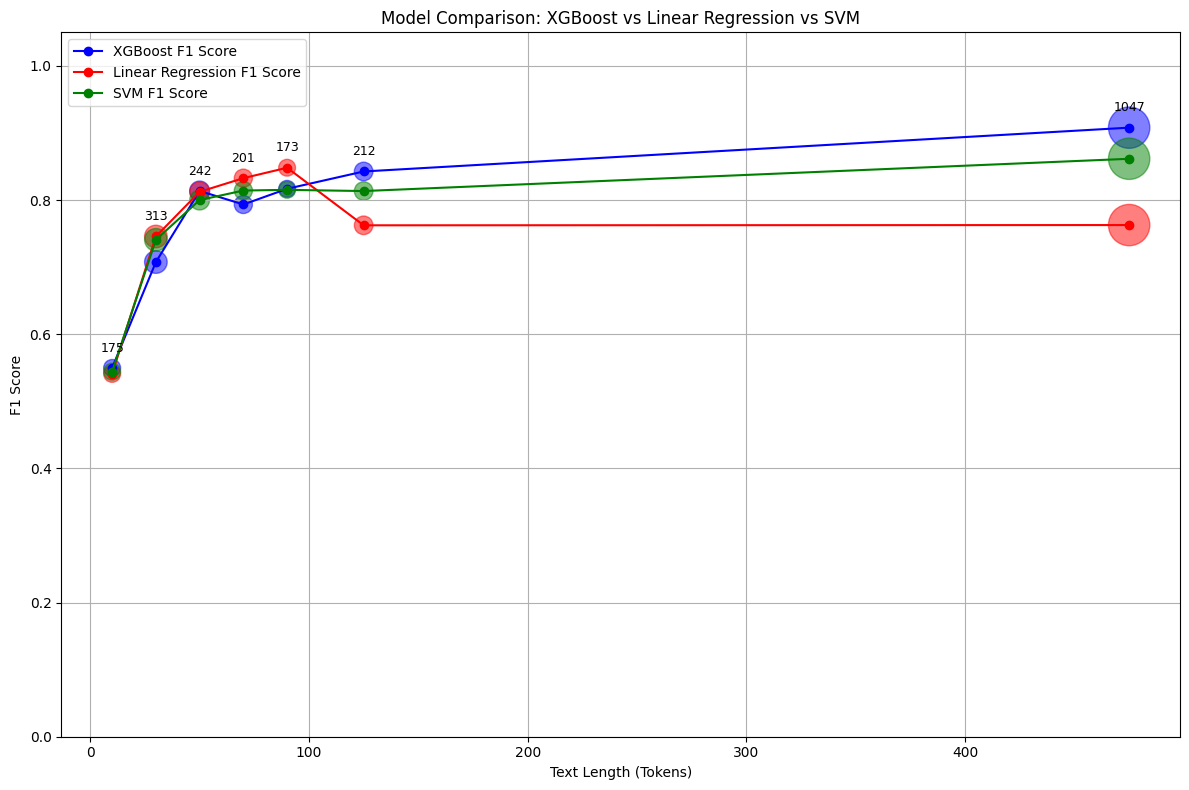

In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import time
import pickle
import os
import logging
import nltk

# --- Configuration & Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK 'punkt' tokenizer...")
    nltk.download('punkt')

# Global Feature Calculation Parameters
NGRAM_NUM = 5
CUTOFF_START = 4
CUTOFF_END = 800
FIXED_FEATURE_SIZE = 2 * NGRAM_NUM + 3

RESERVED_KEYS = {'input', 'common_features', 'avg_common_features',
                 'common_features_ori_vs_allcombined', 'fzwz_features', 'diff'}

# --- Feature Extraction Functions ---

def tokenize_and_normalize(sentence):
    if not isinstance(sentence, str):
        return []
    return [word.lower().strip() for word in sentence.split() if word.strip()]

def extract_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_common_ngrams(tokens1, tokens2, max_n):
    common_counts = [0] * max_n
    for n in range(1, max_n + 1):
        ngrams1 = set(extract_ngrams(tokens1, n))
        if not ngrams1:
            continue
        ngrams2 = set(extract_ngrams(tokens2, n))
        common_counts[n-1] = len(ngrams1.intersection(ngrams2))
    return common_counts

def process_single_record(record):
    original_text = record.get('input', '')
    if not isinstance(original_text, str):
        original_text = str(original_text)
    original_tokens = tokenize_and_normalize(original_text)
    original_len = len(original_tokens)
    if original_len < CUTOFF_START or original_len > CUTOFF_END:
        return None
    rewrite_keys = [k for k in record if k not in RESERVED_KEYS]
    num_valid_rewrites = 0
    total_rewrite_len = 0
    all_common_ngram_counts = [0] * NGRAM_NUM
    fuzz_ratios = []
    token_set_ratios = []
    combined_rewrites_text = ''
    for key in rewrite_keys:
        rewrite_text = record.get(key, '')
        if not isinstance(rewrite_text, str):
            rewrite_text = str(rewrite_text)
        if rewrite_text:
            rewrite_tokens = tokenize_and_normalize(rewrite_text)
            combined_rewrites_text += (' ' + rewrite_text)
            num_valid_rewrites += 1
            total_rewrite_len += len(rewrite_tokens)
            common_counts = calculate_common_ngrams(original_tokens, rewrite_tokens, NGRAM_NUM)
            for i in range(NGRAM_NUM):
                all_common_ngram_counts[i] += common_counts[i]
            try:
                fuzz_ratios.append(fuzz.ratio(original_text, rewrite_text))
                token_set_ratios.append(fuzz.token_set_ratio(original_text, rewrite_text))
            except Exception as e:
                logging.warning(f"Fuzz ratio calculation failed for key '{key}'. Error: {e}")
                fuzz_ratios.append(0.0)
                token_set_ratios.append(0.0)
    processed = {'input': original_text, 'original_len': original_len}
    if num_valid_rewrites > 0:
        processed['avg_common_features'] = [count / num_valid_rewrites for count in all_common_ngram_counts]
        processed['avg_len_diff'] = (total_rewrite_len / num_valid_rewrites) - original_len
        processed['avg_fuzz_ratio'] = np.mean(fuzz_ratios) if fuzz_ratios else 0.0
        processed['avg_token_set_ratio'] = np.mean(token_set_ratios) if token_set_ratios else 0.0
    else:
        processed['avg_common_features'] = [0.0] * NGRAM_NUM
        processed['avg_len_diff'] = -original_len
        processed['avg_fuzz_ratio'] = 0.0
        processed['avg_token_set_ratio'] = 0.0
    combined_tokens = tokenize_and_normalize(combined_rewrites_text.strip())
    processed['common_ori_vs_combined'] = calculate_common_ngrams(original_tokens, combined_tokens, NGRAM_NUM)
    return processed

def extract_feature_vector(processed_record, fixed_size=FIXED_FEATURE_SIZE):
    if processed_record is None:
        return None
    original_len = processed_record.get('original_len', 0)
    norm_factor = float(max(1, original_len))
    features = []
    avg_common = processed_record.get('avg_common_features', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in avg_common[:NGRAM_NUM]])
    ori_vs_combined = processed_record.get('common_ori_vs_combined', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in ori_vs_combined[:NGRAM_NUM]])
    features.append(processed_record.get('avg_fuzz_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_token_set_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_len_diff', 0.0) / norm_factor)
    current_len = len(features)
    if current_len < fixed_size:
        features.extend([0.0] * (fixed_size - current_len))
    elif current_len > fixed_size:
        logging.warning(f"Feature vector size ({current_len}) > fixed size ({fixed_size}). Truncating.")
        features = features[:fixed_size]
    if len(features) != fixed_size:
        logging.error(f"Final feature vector size mismatch: {len(features)} != {fixed_size}. Returning None.")
        return None
    return np.array(features)

def prepare_features_for_dataset(raw_data_list):
    all_features = []
    original_lengths = []
    for i, record in enumerate(raw_data_list):
        if (i + 1) % 500 == 0:
            logging.info(f"Processing record {i+1}/{len(raw_data_list)} for feature extraction...")
        processed = process_single_record(record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                original_lengths.append(processed['original_len'])
    if not all_features:
        logging.warning("No features extracted. Returning empty arrays.")
        return np.empty((0, FIXED_FEATURE_SIZE)), np.array([])
    return np.vstack(all_features), np.array(original_lengths)

# --- Model Training Functions ---

def train_xgboost(X_train, y_train):
    logging.info("Training XGBoost classifier...")
    clf = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
    clf.fit(X_train, y_train)
    logging.info("Training complete.")
    return clf

def train_linear_regression(X_train, y_train):
    logging.info("Training Linear Regression model...")
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    logging.info("Training complete.")
    return lr
def train_svm(X_train, y_train):
    logging.info("Training SVM model...")
    svm_model = SVC(probability=True, random_state=42)
    svm_model.fit(X_train, y_train)
    logging.info("Training complete.")
    return svm_model

# --- Load or Train Models ---

def load_or_train_models(gpt_data_path, human_data_path, model_save_path_xgb, model_save_path_lr, model_save_path_svm, force_retrain=False):
    clf_xgb = None
    clf_lr = None
    clf_svm = None  # New
    
    if not force_retrain:
        try:
            with open(model_save_path_xgb, 'rb') as f:
                clf_xgb = pickle.load(f)
            logging.info(f"Loaded XGBoost model from {model_save_path_xgb}")
        except Exception as e:
            logging.warning(f"Error loading XGBoost model: {e}")
        try:
            with open(model_save_path_lr, 'rb') as f:
                clf_lr = pickle.load(f)
            logging.info(f"Loaded Linear Regression model from {model_save_path_lr}")
        except Exception as e:
            logging.warning(f"Error loading Linear Regression model: {e}")
        try:
            with open(model_save_path_svm, 'rb') as f:
                clf_svm = pickle.load(f)
            logging.info(f"Loaded SVM model from {model_save_path_svm}")
        except Exception as e:
            logging.warning(f"Error loading SVM model: {e}")
    
    if force_retrain or clf_xgb is None or clf_lr is None or clf_svm is None:
        logging.info("--- Starting Model Training ---")
        data_gpt = load_data(gpt_data_path)
        data_human = load_data(human_data_path)
        if data_gpt is None or data_human is None:
            logging.error("Cannot train models without both GPT and Human data. Exiting.")
            return None, None, None
            
        logging.info("Extracting features for GPT data...")
        gpt_features, gpt_lengths = prepare_features_for_dataset(data_gpt)
        logging.info("Extracting features for Human data...")
        human_features, human_lengths = prepare_features_for_dataset(data_human)
        
        if gpt_features.shape[0] > 0 and human_features.shape[0] > 0:
            X = np.concatenate((gpt_features, human_features), axis=0)
            y = np.concatenate((np.ones(gpt_features.shape[0]), np.zeros(human_features.shape[0])), axis=0)
            lengths = np.concatenate((gpt_lengths, human_lengths), axis=0)
            
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=0.2, random_state=42, stratify=y
            )
            
            clf_xgb = train_xgboost(X_train, y_train)
            clf_lr = train_linear_regression(X_train, y_train)
            clf_svm = train_svm(X_train, y_train)
            
            if clf_xgb and clf_lr and clf_svm:
                try:
                    with open(model_save_path_xgb, 'wb') as f:
                        pickle.dump(clf_xgb, f)
                    logging.info(f"Saved XGBoost model to {model_save_path_xgb}")
                    with open(model_save_path_lr, 'wb') as f:
                        pickle.dump(clf_lr, f)
                    logging.info(f"Saved Linear Regression model to {model_save_path_lr}")
                    with open(model_save_path_svm, 'wb') as f:
                        pickle.dump(clf_svm, f)
                    logging.info(f"Saved SVM model to {model_save_path_svm}")
                except Exception as e:
                    logging.error(f"Error saving models: {e}")
            
            # Evaluate all models
            logging.info("Evaluating models on test data...")
            
            # XGBoost predictions
            y_pred_xgb = clf_xgb.predict(X_test)
            y_prob_xgb = clf_xgb.predict_proba(X_test)[:, 1]
            
            # Linear Regression predictions  
            y_pred_lr_cont = clf_lr.predict(X_test)
            y_prob_lr = np.clip(y_pred_lr_cont, 0, 1)
            y_pred_lr = (y_prob_lr > 0.5).astype(int)
            
            # SVM predictions
            y_pred_svm = clf_svm.predict(X_test)
            y_prob_svm = clf_svm.predict_proba(X_test)[:, 1]
            
            # Metrics for all models
            acc_xgb = accuracy_score(y_test, y_pred_xgb)
            f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0.0)
            brier_xgb = brier_score_loss(y_test, y_prob_xgb)
            conf_xgb = np.mean(np.max(clf_xgb.predict_proba(X_test), axis=1))
            
            acc_lr = accuracy_score(y_test, y_pred_lr)
            f1_lr = f1_score(y_test, y_pred_lr, zero_division=0.0)
            brier_lr = brier_score_loss(y_test, y_prob_lr)
            conf_lr = np.mean(np.abs(y_prob_lr - 0.5) * 2)
            
            acc_svm = accuracy_score(y_test, y_pred_svm)
            f1_svm = f1_score(y_test, y_pred_svm, zero_division=0.0)
            brier_svm = brier_score_loss(y_test, y_prob_svm)
            conf_svm = np.mean(np.max(clf_svm.predict_proba(X_test), axis=1))
            
            # Print metrics for all models
            logging.info("--- XGBoost Test Metrics ---")
            logging.info(f" Accuracy: {acc_xgb:.4f}")
            logging.info(f" F1 Score: {f1_xgb:.4f}")
            logging.info(f" Brier Score (MSE): {brier_xgb:.4f}")
            logging.info(f" Average Confidence: {conf_xgb:.4f}")
            logging.info("----------------------------")
            
            logging.info("--- Linear Regression Test Metrics ---")
            logging.info(f" Accuracy: {acc_lr:.4f}")
            logging.info(f" F1 Score: {f1_lr:.4f}")
            logging.info(f" Brier Score (MSE): {brier_lr:.4f}")
            logging.info(f" Average Confidence: {conf_lr:.4f}")
            logging.info("----------------------------")
            
            logging.info("--- SVM Test Metrics ---")
            logging.info(f" Accuracy: {acc_svm:.4f}")
            logging.info(f" F1 Score: {f1_svm:.4f}")
            logging.info(f" Brier Score (MSE): {brier_svm:.4f}")
            logging.info(f" Average Confidence: {conf_svm:.4f}")
            logging.info("----------------------------")
            
            # Plot comparison including SVM
            length_bins = [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100), (100, 150), (150, 800)]
            f1_scores_xgb = []
            f1_scores_lr = []
            f1_scores_svm = []
            x = []
            amounts = []
            
            for start, finish in length_bins:
                mask = (len_test > start) & (len_test <= finish)
                if np.sum(mask) > 0:
                    sub_y_test = y_test[mask]
                    sub_y_pred_xgb = y_pred_xgb[mask]
                    sub_y_pred_lr = y_pred_lr[mask]
                    sub_y_pred_svm = y_pred_svm[mask]
                    
                    f1_scores_xgb.append(f1_score(sub_y_test, sub_y_pred_xgb, zero_division=0.0))
                    f1_scores_lr.append(f1_score(sub_y_test, sub_y_pred_lr, zero_division=0.0))
                    f1_scores_svm.append(f1_score(sub_y_test, sub_y_pred_svm, zero_division=0.0))
                    
                    x.append((start + finish) / 2)
                    amounts.append(len(sub_y_test))
            
            plt.figure(figsize=(12, 8))
            plt.plot(x, f1_scores_xgb, '-o', color='blue', label='XGBoost F1 Score')
            plt.plot(x, f1_scores_lr, '-o', color='red', label='Linear Regression F1 Score')
            plt.plot(x, f1_scores_svm, '-o', color='green', label='SVM F1 Score')
            
            total_amt = sum(amounts)
            percentage_amount = [int(each * 2000.0 / total_amt) for each in amounts]
            
            plt.scatter(x, f1_scores_xgb, s=percentage_amount, alpha=0.5, color='blue')
            plt.scatter(x, f1_scores_lr, s=percentage_amount, alpha=0.5, color='red')
            plt.scatter(x, f1_scores_svm, s=percentage_amount, alpha=0.5, color='green')
            
            for i in range(len(x)):
                plt.text(x[i], max(f1_scores_xgb[i], f1_scores_lr[i], f1_scores_svm[i]) + 0.02,
                        str(amounts[i]), fontsize=9, ha='center', va='bottom')
            
            plt.title('Model Comparison: XGBoost vs Linear Regression vs SVM')
            plt.xlabel('Text Length (Tokens)')
            plt.ylabel('F1 Score')
            plt.legend()
            plt.grid(True)
            plt.ylim(0, 1.05)
            plt.tight_layout()
            plt.savefig('model_comparison_ablation.png')
            logging.info("Saved model comparison plot to 'model_comparison_ablation.png'")
            
        else:
            logging.error("Feature extraction resulted in empty dataset(s). Cannot train.")
            clf_xgb, clf_lr, clf_svm = None, None, None
        logging.info("--- Finished Model Training ---")
    
    return clf_xgb, clf_lr, clf_svm

# --- Data Loading ---

def load_data(file_path):
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
        logging.info(f"Successfully loaded {len(data)} records from {file_path}")
        return data
    except FileNotFoundError:
        logging.error(f"Data file not found: {file_path}")
        return None
    except json.JSONDecodeError:
        logging.error(f"Error decoding JSON from file: {file_path}")
        return None
    except Exception as e:
        logging.error(f"An unexpected error occurred loading {file_path}: {e}")
        return None

# --- Main Execution ---

if __name__ == "__main__":
    main_start_time = time.time()
    GPT_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalgpt.json"
    HUMAN_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalhuman.json"
    MODEL_SAVE_PATH_XGB = 'xgboost_detector_model_simplified.pkl'
    MODEL_SAVE_PATH_LR = 'linear_regression_detector_model.pkl'
    MODEL_SAVE_PATH_SVM = 'svm_detector_model.pkl'
    FORCE_RETRAIN_MODEL = True
    
    classifier_xgb, classifier_lr, classifier_svm = load_or_train_models(
        GPT_TRAIN_DATA, HUMAN_TRAIN_DATA, 
        MODEL_SAVE_PATH_XGB, MODEL_SAVE_PATH_LR, MODEL_SAVE_PATH_SVM,
        FORCE_RETRAIN_MODEL
    )
    
    if classifier_xgb and classifier_lr and classifier_svm:
        logging.info("Models trained and evaluated successfully.")
    else:
        logging.warning("Model training or evaluation failed.")
    
    main_end_time = time.time()
    logging.info(f"\nTotal script runtime: {main_end_time - main_start_time:.2f} seconds")

original with logistic regression

c:\Users\tonyc\Desktop\CITY\CS4186 Comp Vision & Image Processing\Assignment 1\.venv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


0 6000
1 6000
2 6000
3 6000
4 6000
5 6000
6 6000
7 6000
8 6000
9 6000
10 6000
11 6000
12 6000
13 6000
14 6000
15 6000
16 6000
17 6000
18 6000
19 6000
20 6000
21 6000
22 6000
23 6000
24 6000
25 6000
26 6000
27 6000
28 6000
29 6000
30 6000
31 6000
32 6000
33 6000
34 6000
35 6000
36 6000
37 6000
38 6000
39 6000
40 6000
41 6000
42 6000
43 6000
44 6000
45 6000
46 6000
47 6000
48 6000
49 6000
50 6000
51 6000
52 6000
53 6000
54 6000
55 6000
56 6000
57 6000
58 6000
59 6000
60 6000
61 6000
62 6000
63 6000
64 6000
65 6000
66 6000
67 6000
68 6000
69 6000
70 6000
71 6000
72 6000
73 6000
74 6000
75 6000
76 6000
77 6000
78 6000
79 6000
80 6000
81 6000
82 6000
83 6000
84 6000
85 6000
86 6000
87 6000
88 6000
89 6000
90 6000
91 6000
92 6000
93 6000
94 6000
95 6000
96 6000
97 6000
98 6000
99 6000
100 6000
101 6000
102 6000
103 6000
104 6000
105 6000
106 6000
107 6000
108 6000
109 6000
110 6000
111 6000
112 6000
113 6000
114 6000
115 6000
116 6000
117 6000
118 6000
119 6000
120 6000
121 6000
122 6000
123

c:\Users\tonyc\Desktop\CITY\CS4186 Comp Vision & Image Processing\Assignment 1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0 20
Accuracy: 0.5297297297297298 F1 score 0.5583756345177665
              precision    recall  f1-score   support

         0.0       0.55      0.45      0.50        95
         1.0       0.51      0.61      0.56        90

    accuracy                           0.53       185
   macro avg       0.53      0.53      0.53       185
weighted avg       0.53      0.53      0.53       185

20 40
Accuracy: 0.6604938271604939 F1 score 0.7417840375586855
              precision    recall  f1-score   support

         0.0       0.70      0.39      0.50       142
         1.0       0.65      0.87      0.74       182

    accuracy                           0.66       324
   macro avg       0.67      0.63      0.62       324
weighted avg       0.67      0.66      0.64       324

40 60
Accuracy: 0.7266187050359713 F1 score 0.8080808080808081
              precision    recall  f1-score   support

         0.0       0.79      0.39      0.53       107
         1.0       0.71      0.94      0.81      

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


am [185, 324, 278, 209, 161, 193, 1022]

Total script runtime: 772.71 seconds


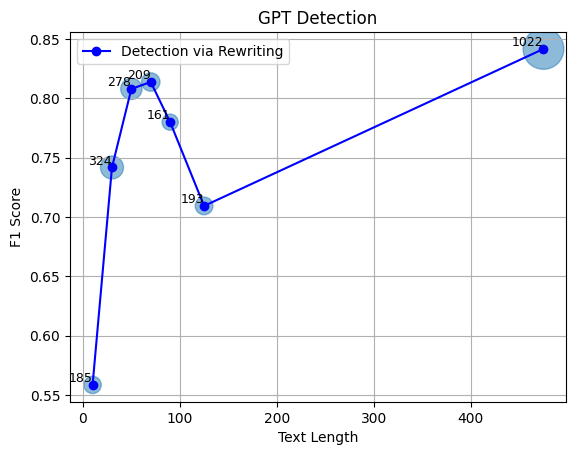

In [1]:

import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
import time
import joblib
from fuzzywuzzy import fuzz
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

def tokenize_and_normalize(sentence):
    # Tokenization and normalization
    return [word.lower().strip() for word in sentence.split()]

def extract_ngrams(tokens, n):
    # Extract n-grams from the list of tokens
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def common_elements(list1, list2):
    # Find common elements between two lists, return a words
    return set(list1) & set(list2)

sentence1 = "I love to play football in the park."
sentence2 = "He loves to play in the park with friends."

ngram_num = 4
cutoff_start = 0
cutoff_end = 6000000

def calculate_sentence_common(sentence1, sentence2):
    tokens1 = tokenize_and_normalize(sentence1)
    tokens2 = tokenize_and_normalize(sentence2)

    # Find common words
    common_words = common_elements(tokens1, tokens2)

    # Find common n-grams (let's say up to 3-grams for this example)
    common_ngrams = set()
    ####################################################

    number_common_hierarchy = [len(list(common_words))]

    for n in range(2, 5):  # 2-grams to 3-grams
        ngrams1 = extract_ngrams(tokens1, n)
        ngrams2 = extract_ngrams(tokens2, n)
        common_ngrams = common_elements(ngrams1, ngrams2) 
        number_common_hierarchy.append(len(list(common_ngrams)))

    return number_common_hierarchy


def sum_for_list(a,b):
    return [aa+bb for aa, bb in zip(a,b)]



def get_data_stat(data_json):
    total_len = len(data_json) #return number of item
    for idxx, each in enumerate(data_json):  #list
        
        original = each['input']  #extract input

        # remove too short ones
        
        raw = tokenize_and_normalize(each['input'])
        if len(raw)<cutoff_start or len(raw)>cutoff_end:
            continue
        else:
            print(idxx, total_len)

        statistic_res = {}
        ratio_fzwz = {}
        all_statistic_res = [0 for i in range(ngram_num)]
        cnt = 0
        whole_combined=''
        for pp in each.keys():
            if pp != 'common_features':
                whole_combined += (' ' + each[pp])
                

                res = calculate_sentence_common(original, each[pp])
                statistic_res[pp] = res
                all_statistic_res = sum_for_list(all_statistic_res, res)

                ratio_fzwz[pp] = [fuzz.ratio(original, each[pp]), fuzz.token_set_ratio(original, each[pp])]
                cnt += 1
        
        each['fzwz_features'] = ratio_fzwz
        each['common_features'] = statistic_res
        each['avg_common_features'] = [a/cnt for a in all_statistic_res]

        each['common_features_ori_vs_allcombined'] = calculate_sentence_common(original, whole_combined)

    return data_json

def get_data_len_diff(data_json):

    diff = []
    for each in data_json:
        original = len(tokenize_and_normalize(each['input']))

        cnt = 0
        t_len = 0
        for pp in each.keys():
            if pp != 'common_features' and pp!='avg_common_features' and pp!='common_features_ori_vs_allcombined' and pp!='fzwz_features':
                # import pdb; pdb.set_trace()
                try:
                    t_len += len(tokenize_and_normalize(each[pp]))
                    cnt += 1
                except:
                    import pdb; pdb.set_trace()
        
        diff.append(t_len/cnt - original)
        each['diff'] = t_len/cnt - original

    return data_json

def xgboost_classifier(gpt, human):

    def get_feature_vec(input_json):
        len_list = []
        all_list = []
        for each in input_json:
            
            try:
                raw = tokenize_and_normalize(each['input'])
                len_list.append(len(raw))
                r_len = len(raw)*1.0
            except:
                import pdb; pdb.set_trace()
            each_data_fea  = []
            if len(raw)<cutoff_start or len(raw)>cutoff_end:
                continue

            # each_data_fea  = [len(raw) / 100.]
            
            each_data_fea = [ind_d / r_len for ind_d in each['avg_common_features']]
            for ek in each['common_features'].keys():
                each_data_fea.extend([ind_d / r_len for ind_d in each['common_features'][ek]])
            
            each_data_fea.extend([ind_d / r_len for ind_d in each['common_features_ori_vs_allcombined']])

            for ek in each['fzwz_features'].keys():
                each_data_fea.extend(each['fzwz_features'][ek])

            all_list.append(np.array(each_data_fea))
        all_list = np.vstack(all_list)

        len_list = np.array(len_list)

        return all_list, len_list
    
    gpt_all, g_len = get_feature_vec(gpt)
    human_all, h_len = get_feature_vec(human)

    # reblanced
    g_train, g_test, yg_train, yg_test, gl_train, gl_test = train_test_split(gpt_all, np.ones(gpt_all.shape[0]), g_len, test_size=0.2, random_state=42)
    h_train, h_test, yh_train, yh_test, hl_train, hl_test = train_test_split(human_all, np.zeros(human_all.shape[0]), h_len, test_size=0.2, random_state=42)

    X_train = np.concatenate((g_train, g_train, h_train), axis=0)
    y_train = np.concatenate((yg_train, yg_train, yh_train), axis=0)


    X_test = np.concatenate((g_test, h_test), axis=0)
    y_test = np.concatenate((yg_test, yh_test), axis=0)

    len_test = np.concatenate((gl_test, hl_test), axis=0)



    # # # Logistic regression
    clf = LogisticRegression(max_iter=2000) #new
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test) # 66.22
    
    
    #prob = clf.predict_proba(X_test)[0][1] ###predict prob
    #print(prob*100)
    #joblib.dump(clf,'clf.pkl')

    from sklearn.metrics import accuracy_score, classification_report, f1_score

    ans = []
    x = []
    amount = []
    for start, finish in [(0, 20), (20, 40), (40, 60), (60, 80), (80, 100), (100, 150), (150,  800)]:
        sub_y_test = []
        sub_y_pred = []

        for jj in range(len(len_test)):
            l = len_test[jj]
            if l>start and l<=finish:
                sub_y_test.append(y_test[jj])
                sub_y_pred.append(y_pred[jj])

        print(start, finish)
        print("Accuracy:", accuracy_score(sub_y_test, sub_y_pred), "F1 score", f1_score(sub_y_test, sub_y_pred))
        print(classification_report(sub_y_test, sub_y_pred))
        ans.append(f1_score(sub_y_test, sub_y_pred))
        x.append((start+finish)/2)
        amount.append(len(sub_y_pred))
    
    plt.figure()
    plt.plot(x, ans, '-o', color='blue', label='Detection via Rewriting')

    total_amt = sum(amount)
    percentage_amount = [int(each*1.0/total_amt * 2000) for each in amount]
    plt.scatter(x, ans, s=percentage_amount, alpha=0.5)  # Add scatter plot
    for i in range(len(x)):
        plt.text(x[i], ans[i], str(amount[i]), fontsize=9, ha='right', va='bottom')

    plt.title('GPT Detection')
    plt.xlabel('Text Length')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.savefig('len_ablation.eps')

    print('am', amount)



#Read JSON files
with open("C:/Users/tonyc/Desktop/dataset/finalgpt.json", "r") as f:  # XGBoost best
    data_gpt = json.load(f)
with open("C:/Users/tonyc/Desktop/dataset/finalhuman.json", "r") as f:
    data_human = json.load(f)
main_start_time = time.time()
gpt = get_data_stat(data_gpt)
human = get_data_stat(data_human)

gpt = get_data_len_diff(gpt)
human = get_data_len_diff(human)
xgboost_classifier(gpt, human)
main_end_time = time.time()
print(f"\nTotal script runtime: {main_end_time - main_start_time:.2f} seconds")


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import xgboost as xgb
from sklearn.model_selection import train_test_split
import time
import pickle
import os
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, GPT2Tokenizer, GPT2LMHeadModel
import torch
import logging
import tkinter as tk
from tkinter import filedialog
from nltk.tokenize import sent_tokenize
from pdfminer.high_level import extract_text
import nltk
import shap

# --- Configuration & Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK 'punkt' tokenizer...")
    nltk.download('punkt')

# Global Feature Calculation Parameters
NGRAM_NUM = 5
CUTOFF_START = 4
CUTOFF_END = 800
FIXED_FEATURE_SIZE = 2 * NGRAM_NUM + 3

RESERVED_KEYS = {'input', 'common_features', 'avg_common_features',
                 'common_features_ori_vs_allcombined', 'fzwz_features', 'diff'}

T5_PROMPTS = [
    "Help me polish this",
    "Rewrite this for me",
    "Make this fluent while doing minimal change",
    "Refine this for me please, just show me the out put",
    "Concise this for me and keep all the information"
]

def tokenize_and_normalize(sentence):
    if not isinstance(sentence, str):
        return []
    return [word.lower().strip() for word in sentence.split() if word.strip()]

def extract_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_common_ngrams(tokens1, tokens2, max_n):
    common_counts = [0] * max_n
    for n in range(1, max_n + 1):
        ngrams1 = set(extract_ngrams(tokens1, n))
        if not ngrams1:
            continue
        ngrams2 = set(extract_ngrams(tokens2, n))
        common_counts[n-1] = len(ngrams1.intersection(ngrams2))
    return common_counts

def process_single_record(record):
    original_text = record.get('input', '')
    if not isinstance(original_text, str):
        original_text = str(original_text)
    original_tokens = tokenize_and_normalize(original_text)
    original_len = len(original_tokens)
    if original_len < CUTOFF_START or original_len > CUTOFF_END:
        return None
    rewrite_keys = [k for k in record if k not in RESERVED_KEYS]
    num_valid_rewrites = 0
    total_rewrite_len = 0
    all_common_ngram_counts = [0] * NGRAM_NUM
    fuzz_ratios = []
    token_set_ratios = []
    combined_rewrites_text = ''
    for key in rewrite_keys:
        rewrite_text = record.get(key, '')
        if not isinstance(rewrite_text, str):
            rewrite_text = str(rewrite_text)
        if rewrite_text:
            rewrite_tokens = tokenize_and_normalize(rewrite_text)
            combined_rewrites_text += (' ' + rewrite_text)
            num_valid_rewrites += 1
            total_rewrite_len += len(rewrite_tokens)
            common_counts = calculate_common_ngrams(original_tokens, rewrite_tokens, NGRAM_NUM)
            for i in range(NGRAM_NUM):
                all_common_ngram_counts[i] += common_counts[i]
            fuzz_ratios.append(fuzz.ratio(original_text, rewrite_text))
            token_set_ratios.append(fuzz.token_set_ratio(original_text, rewrite_text))
    processed = {'input': original_text, 'original_len': original_len}
    if num_valid_rewrites > 0:
        processed['avg_common_features'] = [count / num_valid_rewrites for count in all_common_ngram_counts]
        processed['avg_len_diff'] = (total_rewrite_len / num_valid_rewrites) - original_len
        processed['avg_fuzz_ratio'] = np.mean(fuzz_ratios) if fuzz_ratios else 0.0
        processed['avg_token_set_ratio'] = np.mean(token_set_ratios) if token_set_ratios else 0.0
    else:
        processed['avg_common_features'] = [0.0] * NGRAM_NUM
        processed['avg_len_diff'] = -original_len
        processed['avg_fuzz_ratio'] = 0.0
        processed['avg_token_set_ratio'] = 0.0
    combined_tokens = tokenize_and_normalize(combined_rewrites_text.strip())
    processed['common_ori_vs_combined'] = calculate_common_ngrams(original_tokens, combined_tokens, NGRAM_NUM)
    return processed

def extract_feature_vector(processed_record, fixed_size=FIXED_FEATURE_SIZE):
    if processed_record is None:
        return None
    original_len = processed_record.get('original_len', 0)
    norm_factor = float(max(1, original_len))
    features = []
    avg_common = processed_record.get('avg_common_features', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in avg_common[:NGRAM_NUM]])
    ori_vs_combined = processed_record.get('common_ori_vs_combined', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in ori_vs_combined[:NGRAM_NUM]])
    features.append(processed_record.get('avg_fuzz_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_token_set_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_len_diff', 0.0) / norm_factor)
    if len(features) != fixed_size:
        features.extend([0.0] * (fixed_size - len(features)))
    return np.array(features)

def prepare_features_for_dataset(raw_data_list):
    all_features = []
    original_lengths = []
    for i, record in enumerate(raw_data_list):
        if (i + 1) % 500 == 0:
            logging.info(f"Processing record {i+1}/{len(raw_data_list)}...")
        processed = process_single_record(record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                original_lengths.append(processed['original_len'])
    return np.vstack(all_features) if all_features else np.empty((0, FIXED_FEATURE_SIZE)), np.array(original_lengths)

def train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths):
    if gpt_features.shape[0] == 0 or human_features.shape[0] == 0:
        logging.error("Empty feature sets. Cannot train.")
        return None
    X = np.concatenate((gpt_features, human_features), axis=0)
    y = np.concatenate((np.ones(gpt_features.shape[0]), np.zeros(human_features.shape[0])), axis=0)
    lengths = np.concatenate((gpt_lengths, human_lengths), axis=0)
    X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
        X, y, lengths, test_size=0.2, random_state=42, stratify=y
    )
    # Improved XGBoost parameters for better accuracy
    clf = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=6,  # Increased depth
        learning_rate=0.1,  # Adjusted learning rate
        n_estimators=200,  # More trees
        random_state=42
    )
    clf.fit(X_train, y_train)
    if len(y_test) > 0:
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)
        logging.info(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}, F1: {f1_score(y_test, y_pred):.4f}")
    return clf

def load_t5_model(model_name='t5-small'):
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model.to(device)
        logging.info(f"T5 model '{model_name}' loaded on {device}.")
        return tokenizer, model, device
    except Exception as e:
        logging.error(f"T5 loading error: {e}")
        return None, None, None

def generate_rewrites_with_prompts(text, tokenizer, model, device, prompts=T5_PROMPTS):
    if not tokenizer or not model:
        return {}
    rewritten_dict = {}
    for i, prompt in enumerate(prompts):
        input_text = f"{prompt}: {text}"
        try:
            inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True).to(device)
            outputs = model.generate(**inputs, max_length=512, num_beams=5, do_sample=True, temperature=1.5)
            rewrite = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            rewritten_dict[f'rewrite_{i+1}'] = rewrite
        except Exception:
            rewritten_dict[f'rewrite_{i+1}'] = ""
    return rewritten_dict

def classify_text(text, clf, t5_tokenizer, t5_model, t5_device, explainer=None):
    if not text or not clf or not t5_tokenizer or not t5_model:
        return None, None, None
    rewrites = generate_rewrites_with_prompts(text, t5_tokenizer, t5_model, t5_device)
    data_record = {'input': text}
    data_record.update(rewrites)
    processed = process_single_record(data_record)
    if not processed:
        return None, None, None
    feature_vector = extract_feature_vector(processed)
    if feature_vector is None:
        return None, None, None
    prob = clf.predict_proba(feature_vector.reshape(1, -1))[0]
    prob_gpt = prob[1]
    prediction = "AI-Generated" if prob_gpt > 0.5 else "Human-Written"
    confidence = prob_gpt if prediction == "AI-Generated" else prob[0]
    shap_values = explainer.shap_values(feature_vector.reshape(1, -1)) if explainer else None
    return prediction, confidence, shap_values

def load_or_train_model(gpt_data_path, human_data_path, model_save_path, force_retrain=False):
    if not force_retrain and os.path.exists(model_save_path):
        try:
            with open(model_save_path, 'rb') as f:
                return pickle.load(f)
        except Exception:
            force_retrain = True
    data_gpt = json.load(open(gpt_data_path, 'r', encoding='utf-8'))
    data_human = json.load(open(human_data_path, 'r', encoding='utf-8'))
    gpt_features, gpt_lengths = prepare_features_for_dataset(data_gpt)
    human_features, human_lengths = prepare_features_for_dataset(data_human)
    clf = train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths)
    if clf:
        with open(model_save_path, 'wb') as f:
            pickle.dump(clf, f)
    return clf

# --- GUI Functions ---
def import_pdf(text_widget, status_widget):
    file_path = filedialog.askopenfilename(filetypes=[("PDF files", "*.pdf")])
    if file_path:
        try:
            text = extract_text(file_path)
            text_widget.delete("1.0", tk.END)
            text_widget.insert(tk.END, text)
            status_widget.config(text="PDF loaded.")
        except Exception as e:
            status_widget.config(text=f"Error: {e}")

def scan_text(input_widget, result_widget, prediction_label, status_widget, clf, t5_tok, t5_mod, t5_dev, explainer):
    status_widget.config(text="Scanning...")
    root.update()
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to scan.")
        return
    result_widget.config(state="normal")
    result_widget.delete("1.0", tk.END)
    result_widget.tag_remove("suspected", "1.0", tk.END)
    result_widget.insert(tk.END, full_text)
    result = classify_text(full_text, clf, t5_tok, t5_mod, t5_dev, explainer)
    if not result:
        status_widget.config(text="Classification error.")
        result_widget.config(state="disabled")
        return
    overall_prediction, overall_confidence, _ = result
    prediction_label.config(text=f"Prediction: {overall_prediction} ({overall_confidence*100:.2f}%)")
    sentences = sent_tokenize(full_text)
    if sentences:
        highlighted_count = highlight_suspected_sentences(result_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer)
        logging.info(f"Highlighted {highlighted_count}/{len(sentences)} sentences.")
    status_widget.config(text="Scan complete.")
    result_widget.config(state="disabled")

def highlight_suspected_sentences(text_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer):
    text_widget.tag_config("suspected", background="yellow")
    highlighted_count = 0
    for sentence in sentences:
        prediction, confidence, shap_values = classify_text(sentence, clf, t5_tok, t5_mod, t5_dev, explainer)
        logging.info(f"Sentence: {sentence[:50]}... | Pred: {prediction} | Conf: {confidence:.4f}")
        if prediction == "AI-Generated" and shap_values is not None:
            shap_sum = np.sum(shap_values[0]) if shap_values[0].ndim == 1 else np.sum(shap_values[0][1])
            logging.info(f"SHAP sum: {shap_sum:.4f}")
            # Lowered threshold to 0.5 for more highlights
            if shap_sum > 0.3:
                start_pos = text_widget.search(sentence, "1.0", stopindex="end")
                if start_pos:
                    end_pos = f"{start_pos}+{len(sentence)}c"
                    text_widget.tag_add("suspected", start_pos, end_pos)
                    highlighted_count += 1
                    logging.info(f"Highlighted: {sentence[:50]}...")
    return highlighted_count

def save_to_json(input_widget, t5_tok, t5_mod, t5_dev, status_widget):
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to save.")
        return
    rewrites = generate_rewrites_with_prompts(full_text, t5_tok, t5_mod, t5_dev)
    data_record = {'input': full_text, **rewrites}
    file_path = filedialog.asksaveasfilename(defaultextension=".json", filetypes=[("JSON files", "*.json")])
    if file_path:
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(data_record, f, ensure_ascii=False, indent=4)
        status_widget.config(text=f"Saved to {file_path}")

# --- Main Execution ---
if __name__ == "__main__":
    GPT_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalgpt.json"
    HUMAN_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalhuman.json"
    MODEL_SAVE_PATH = 'xgboost_detector_model_simplified.pkl'
    FORCE_RETRAIN_MODEL = True
    classifier = load_or_train_model(GPT_TRAIN_DATA, HUMAN_TRAIN_DATA, MODEL_SAVE_PATH, FORCE_RETRAIN_MODEL)
    if classifier:
        t5_tokenizer, t5_model, t5_device = load_t5_model('t5-small')
        explainer = shap.TreeExplainer(classifier)
        root = tk.Tk()
        root.title("AI Text Detector")
        root.geometry("1200x600")
        main_frame = tk.Frame(root)
        main_frame.pack(fill="both", expand=True)
        left_frame = tk.Frame(main_frame)
        left_frame.pack(side="left", fill="both", expand=True, padx=10, pady=10)
        tk.Label(left_frame, text="Input Text:").pack(anchor="w")
        input_text = tk.Text(left_frame, height=20, width=50)
        input_text.pack(fill="both", expand=True)
        button_frame = tk.Frame(left_frame)
        button_frame.pack(side="bottom", fill="x")
        tk.Button(button_frame, text="Import PDF", command=lambda: import_pdf(input_text, status_label)).pack(side="left", padx=10)
        tk.Button(button_frame, text="Scan", command=lambda: scan_text(input_text, result_text, prediction_label, status_label, classifier, t5_tokenizer, t5_model, t5_device, explainer)).pack(side="left", padx=10)
        tk.Button(button_frame, text="Save to JSON", command=lambda: save_to_json(input_text, t5_tokenizer, t5_model, t5_device, status_label)).pack(side="left", padx=10)
        right_frame = tk.Frame(main_frame)
        right_frame.pack(side="right", fill="both", expand=True, padx=10, pady=10)
        prediction_label = tk.Label(right_frame, text="")
        prediction_label.pack(fill="x")
        tk.Label(right_frame, text="Scan Results:").pack(anchor="w")
        result_text = tk.Text(right_frame, height=20, width=50)
        result_text.pack(fill="both", expand=True)
        status_label = tk.Label(root, text="Ready", anchor="w", relief="sunken")
        status_label.pack(side="bottom", fill="x")
        root.mainloop()

2025-04-11 01:33:08,533 - INFO - Processing record 500/6000...
2025-04-11 01:33:09,648 - INFO - Processing record 1000/6000...
2025-04-11 01:33:10,749 - INFO - Processing record 1500/6000...
2025-04-11 01:33:11,626 - INFO - Processing record 2000/6000...
2025-04-11 01:33:12,648 - INFO - Processing record 2500/6000...
2025-04-11 01:33:13,812 - INFO - Processing record 3000/6000...
2025-04-11 01:33:16,525 - INFO - Processing record 3500/6000...
2025-04-11 01:33:22,006 - INFO - Processing record 4000/6000...
2025-04-11 01:33:27,932 - INFO - Processing record 4500/6000...
2025-04-11 01:33:31,297 - INFO - Processing record 5000/6000...
2025-04-11 01:33:35,325 - INFO - Processing record 5500/6000...
2025-04-11 01:33:39,388 - INFO - Processing record 6000/6000...
2025-04-11 01:33:42,735 - INFO - Processing record 500/6000...
2025-04-11 01:33:44,789 - INFO - Processing record 1000/6000...
2025-04-11 01:33:46,670 - INFO - Processing record 1500/6000...
2025-04-11 01:33:48,717 - INFO - Processin

Add readability calculation

c:\Users\tonyc\Desktop\CITY\CS4186 Comp Vision & Image Processing\Assignment 1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-11 17:53:49,553 - INFO - --- Starting Model Training ---
2025-04-11 17:53:49,854 - INFO - Successfully loaded 6000 records from C:/Users/tonyc/Desktop/dataset/finalgpt.json
2025-04-11 17:53:50,243 - INFO - Successfully loaded 6000 records from C:/Users/tonyc/Desktop/dataset/finalhuman.json
2025-04-11 17:53:50,245 - INFO - Extracting features for GPT data...
2025-04-11 17:53:55,490 - INFO - Processing record 500/6000 for feature extraction...
2025-04-11 17:53:58,501 - INFO - Processing record 1000/6000 for feature extraction...
2025-04-11 17:54:01,257 - INFO - Processing record 1500/6000 for feature extraction...
2025-04-11 17:54:03,589 - INFO - Processing record 2000/6000 for

2025-04-11 17:57:53,431 - WARNING - From c:\Users\tonyc\Desktop\CITY\CS4186 Comp Vision & Image Processing\Assignment 1\.venv\Lib\site-packages\tf_keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.

2025-04-11 17:57:55,704 - INFO - 
Total script runtime: 246.15 seconds
2025-04-11 17:58:14,305 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-11 17:58:14,327 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-11 17:58:14,348 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast 

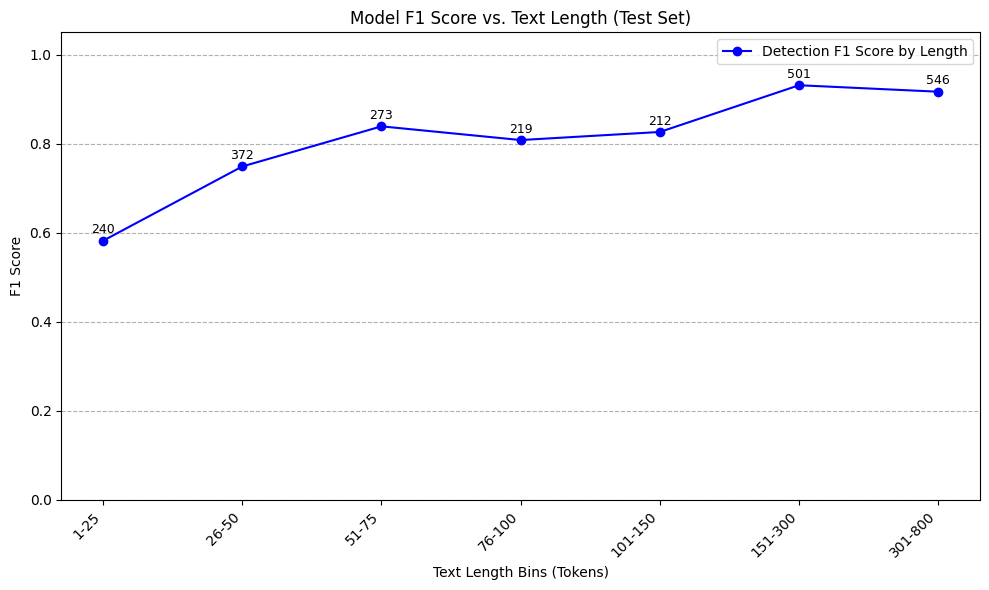

In [2]:

import json
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import xgboost as xgb
from sklearn.model_selection import train_test_split
import time
import pickle
import os
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, GPT2Tokenizer, GPT2LMHeadModel
import torch
import logging
import tkinter as tk
from tkinter import filedialog
from nltk.tokenize import sent_tokenize
from pdfminer.high_level import extract_text
import nltk
import shap
import textstat  # New import for readability calculation

# --- Configuration & Setup ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK 'punkt' tokenizer...")
    nltk.download('punkt')

# Global Feature Calculation Parameters
NGRAM_NUM = 5
CUTOFF_START = 4
CUTOFF_END = 800
# Updated fixed feature size: previous size (2*NGRAM_NUM + 3) plus one new readability feature = 2*5+3+1 = 14
FIXED_FEATURE_SIZE = 2 * NGRAM_NUM + 4  
ESERVED_KEYS = {'input', 'common_features', 'avg_common_features',
                'common_features_ori_vs_allcombined', 'fzwz_features', 'diff'}
T5_PROMPTS = [
    "Help me polish this",
    "Rewrite this for me",
    "Make this fluent while doing minimal change",
    "Refine this for me please, just show me the out put",
    "Concise this for me and keep all the information"
]
NUM_T5_REWRITES = len(T5_PROMPTS)

def tokenize_and_normalize(sentence):
    if not isinstance(sentence, str):
        return []
    return [word.lower().strip() for word in sentence.split() if word.strip()]

def extract_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_common_ngrams(tokens1, tokens2, max_n):
    common_counts = [0] * max_n
    for n in range(1, max_n + 1):
        ngrams1 = set(extract_ngrams(tokens1, n))
        if not ngrams1:
            continue
        ngrams2 = set(extract_ngrams(tokens2, n))
        common_counts[n-1] = len(ngrams1.intersection(ngrams2))
    return common_counts

def process_single_record(record):
    original_text = record.get('input', '')
    if not isinstance(original_text, str):
        original_text = str(original_text)
    original_tokens = tokenize_and_normalize(original_text)
    original_len = len(original_tokens)
    if original_len < CUTOFF_START or original_len > CUTOFF_END:
        return None
    rewrite_keys = [k for k in record if k not in ESERVED_KEYS]
    num_valid_rewrites = 0
    total_rewrite_len = 0
    all_common_ngram_counts = [0] * NGRAM_NUM
    fuzz_ratios = []
    token_set_ratios = []
    combined_rewrites_text = ''
    # New lists to track readability scores for rewrites
    rewrite_readabilities = []
    for key in rewrite_keys:
        rewrite_text = record.get(key, '')
        if not isinstance(rewrite_text, str):
            rewrite_text = str(rewrite_text)
        if rewrite_text:
            rewrite_tokens = tokenize_and_normalize(rewrite_text)
            combined_rewrites_text += (' ' + rewrite_text)
            num_valid_rewrites += 1
            total_rewrite_len += len(rewrite_tokens)
            common_counts = calculate_common_ngrams(original_tokens, rewrite_tokens, NGRAM_NUM)
            for i in range(NGRAM_NUM):
                all_common_ngram_counts[i] += common_counts[i]
            try:
                fuzz_ratios.append(fuzz.ratio(original_text, rewrite_text))
                token_set_ratios.append(fuzz.token_set_ratio(original_text, rewrite_text))
            except Exception as e:
                logging.warning(f"Fuzz ratio calculation failed for key '{key}'. Error: {e}")
                fuzz_ratios.append(0.0)
                token_set_ratios.append(0.0)
            # New: compute readability for each rewrite using Flesch Reading Ease
            try:
                rewrite_read = textstat.flesch_reading_ease(rewrite_text)
                rewrite_readabilities.append(rewrite_read)
            except Exception as e:
                logging.warning(f"Readability calculation failed for rewrite key '{key}'. Error: {e}")
    processed = {'input': original_text, 'original_len': original_len}
    # New: compute original readability
    try:
        orig_readability = textstat.flesch_reading_ease(original_text)
    except Exception as e:
        logging.warning(f"Readability calculation failed for original text. Error: {e}")
        orig_readability = 0.0
    if num_valid_rewrites > 0:
        processed['avg_common_features'] = [count / num_valid_rewrites for count in all_common_ngram_counts]
        processed['avg_len_diff'] = (total_rewrite_len / num_valid_rewrites) - original_len
        processed['avg_fuzz_ratio'] = np.mean(fuzz_ratios) if fuzz_ratios else 0.0
        processed['avg_token_set_ratio'] = np.mean(token_set_ratios) if token_set_ratios else 0.0
        # New: compute average readability difference (rewrite score minus original score)
        if rewrite_readabilities:
            avg_readability_diff = np.mean([rw - orig_readability for rw in rewrite_readabilities])
        else:
            avg_readability_diff = 0.0
        processed['avg_readability_diff'] = avg_readability_diff
    else:
        processed['avg_common_features'] = [0.0] * NGRAM_NUM
        processed['avg_len_diff'] = -original_len
        processed['avg_fuzz_ratio'] = 0.0
        processed['avg_token_set_ratio'] = 0.0
        processed['avg_readability_diff'] = 0.0
    combined_tokens = tokenize_and_normalize(combined_rewrites_text.strip())
    processed['common_ori_vs_combined'] = calculate_common_ngrams(original_tokens, combined_tokens, NGRAM_NUM)
    return processed

def extract_feature_vector(processed_record, fixed_size=FIXED_FEATURE_SIZE):
    if processed_record is None:
        return None
    original_len = processed_record.get('original_len', 0)
    norm_factor = float(max(1, original_len))
    features = []
    avg_common = processed_record.get('avg_common_features', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in avg_common[:NGRAM_NUM]])
    ori_vs_combined = processed_record.get('common_ori_vs_combined', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in ori_vs_combined[:NGRAM_NUM]])
    features.append(processed_record.get('avg_fuzz_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_token_set_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_len_diff', 0.0) / norm_factor)
    # New: append the average readability difference (unscaled)
    features.append(processed_record.get('avg_readability_diff', 0.0))
    current_len = len(features)
    if current_len < fixed_size:
        features.extend([0.0] * (fixed_size - current_len))
    elif current_len > fixed_size:
        logging.warning(f"Feature vector size ({current_len}) > fixed size ({fixed_size}). Truncating.")
        features = features[:fixed_size]
    if len(features) != fixed_size:
        logging.error(f"Final feature vector size mismatch: {len(features)} != {fixed_size}. Returning None.")
        return None
    return np.array(features)

def prepare_features_for_dataset(raw_data_list):
    all_features = []
    original_lengths = []
    for i, record in enumerate(raw_data_list):
        if (i + 1) % 500 == 0:
            logging.info(f"Processing record {i+1}/{len(raw_data_list)} for feature extraction...")
        processed = process_single_record(record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                original_lengths.append(processed['original_len'])
    if not all_features:
        logging.warning("No features extracted. Returning empty arrays.")
        return np.empty((0, FIXED_FEATURE_SIZE)), np.array([])
    return np.vstack(all_features), np.array(original_lengths)

def train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths):
    if gpt_features.shape[0] == 0 or human_features.shape[0] == 0:
        logging.error("Cannot train model: One or both feature sets are empty.")
        return None
    logging.info(f"Training data shapes: GPT={gpt_features.shape}, Human={human_features.shape}")
    X = np.concatenate((gpt_features, human_features), axis=0)
    y = np.concatenate((np.ones(gpt_features.shape[0]), np.zeros(human_features.shape[0])), axis=0)
    lengths = np.concatenate((gpt_lengths, human_lengths), axis=0)
    min_samples_per_class = 10
    test_size = 0.2
    if gpt_features.shape[0] < min_samples_per_class or human_features.shape[0] < min_samples_per_class or (gpt_features.shape[0] + human_features.shape[0]) * test_size < 2:
        logging.warning("Not enough samples for train/test split. Training on all data.")
        X_train, y_train = X, y
        X_test, y_test, len_test = None, None, None
    else:
        try:
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=test_size, random_state=42, stratify=y
            )
            logging.info(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
        except ValueError:
            logging.warning("Stratified split failed. Falling back to non-stratified.")
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=test_size, random_state=42
            )
            logging.info(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
    logging.info("Training XGBoost classifier...")
    clf = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
    clf.fit(X_train, y_train)
    logging.info("Training complete.")
    if X_test is not None and y_test is not None and len(y_test) > 0:
        logging.info("Evaluating classifier on test data...")
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0.0)
        brier = brier_score_loss(y_test, y_prob[:, 1])
        confidence = np.mean(np.max(y_prob, axis=1))
        logging.info("--- Overall Test Metrics ---")
        logging.info(f" Accuracy: {accuracy:.4f}")
        logging.info(f" F1 Score: {f1:.4f}")
        logging.info(f" Brier Score (MSE): {brier:.4f}")
        logging.info(f" Average Confidence: {confidence:.4f}")
        logging.info("----------------------------")
        plot_length_ablation(y_test, y_pred, len_test, "len_ablation_f1.png")
    return clf

def plot_length_ablation(y_true, y_pred, lengths, filename="length_ablation.png"):
    logging.info("Performing length ablation study...")
    length_bins = [(0, 25), (25, 50), (50, 75), (75, 100), (100, 150), (150, 300), (300, CUTOFF_END)]
    f1_scores = []
    bin_labels = []
    bin_counts = []
    for start, finish in length_bins:
        mask = (lengths > start) & (lengths <= finish)
        if np.sum(mask) > 0:
            sub_y_true = y_true[mask]
            sub_y_pred = y_pred[mask]
            sub_f1 = f1_score(sub_y_true, sub_y_pred, zero_division=0.0)
            count = len(sub_y_true)
            label = f"{start+1}-{finish}"
            f1_scores.append(sub_f1)
            bin_labels.append(label)
            bin_counts.append(count)
            logging.info(f" Length {label}: F1={sub_f1:.4f}, Samples={count}")
        else:
            logging.info(f" Length {start+1}-{finish}: No samples in this bin.")
    if bin_labels and f1_scores:
        plt.figure(figsize=(10, 6))
        plt.plot(bin_labels, f1_scores, '-o', color='blue', label='Detection F1 Score by Length')
        for i, count in enumerate(bin_counts):
            if count > 0:
                plt.text(bin_labels[i], f1_scores[i] + 0.01, str(count), fontsize=9, ha='center', va='bottom')
        plt.title('Model F1 Score vs. Text Length (Test Set)')
        plt.xlabel('Text Length Bins (Tokens)')
        plt.ylabel('F1 Score')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True, axis='y', linestyle='--')
        plt.tight_layout()
        try:
            plt.savefig(filename)
            logging.info(f"Saved length ablation plot to {filename}")
        except Exception as e:
            logging.warning(f"Could not save plot '{filename}'. Error: {e}")
    else:
        logging.info("No data available for length ablation plot.")

def load_t5_model(model_name='t5-small'):
    try:
        logging.info(f"Loading T5 model ({model_name}) and tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model.to(device)
        logging.info(f"T5 model '{model_name}' loaded successfully on {device}.")
        return tokenizer, model, device
    except Exception as e:
        logging.error(f"Error loading T5 model/tokenizer '{model_name}': {e}")
        return None, None, None

def generate_rewrites_with_prompts(text, tokenizer, model, device, prompts=T5_PROMPTS, temperature=1.5, num_beams=5):
    if not tokenizer or not model:
        logging.error("T5 Tokenizer or Model not available for generating rewrites.")
        return {}
    rewritten_dict = {}
    for i, prompt in enumerate(prompts):
        input_text = f"{prompt}: {text}"
        try:
            inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True, padding=True).to(device)
            input_length = inputs['input_ids'].shape[1]
            max_len = min(int(input_length * 1.5) + 20, 512)
            min_len = max(10, input_length // 2)
            if min_len >= max_len:
                min_len = max(1, max_len // 2)
            outputs = model.generate(
                **inputs,
                num_beams=num_beams,
                do_sample=True,
                temperature=temperature,
                top_k=50,
                top_p=0.95,
                num_return_sequences=1,
                max_length=max_len,
                min_length=min_len,
                early_stopping=True,
                repetition_penalty=1.2
            )
            rewrite = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            rewrite_key = f'rewrite_{i+1}'
            rewritten_dict[rewrite_key] = rewrite
        except Exception as e:
            logging.error(f"Error generating rewrite for prompt '{prompt}': {e}")
            rewritten_dict[f'rewrite_{i+1}'] = ""
    return rewritten_dict

def classify_text(text, clf, t5_tokenizer, t5_model, t5_device, explainer=None):
    if not text or not isinstance(text, str):
        logging.error("Invalid input text provided.")
        return None, None, None
    if not clf or not t5_tokenizer or not t5_model:
        logging.error("Classifier or T5 model/tokenizer not available.")
        return None, None, None
    logging.info("Generating rewrites for input...")
    start_time = time.time()
    rewrites = generate_rewrites_with_prompts(text, t5_tokenizer, t5_model, t5_device)
    logging.info(f"Generated {len([r for r in rewrites.values() if r])} non-empty rewrites in {time.time() - start_time:.2f}s.")
    data_record = {'input': text}
    data_record.update(rewrites)
    processed = process_single_record(data_record)
    if not processed:
        logging.warning("Input text filtered out (e.g., length). Cannot classify.")
        return None, None, None
    feature_vector = extract_feature_vector(processed)
    if feature_vector is None:
        logging.error("Feature extraction failed for the input text.")
        return None, None, None
    try:
        prob = clf.predict_proba(feature_vector.reshape(1, -1))[0]
        prob_gpt = prob[1]
        prediction = "AI-Generated" if prob_gpt > 0.5 else "Human-Written"
        confidence = prob_gpt if prediction == "AI-Generated" else prob[0]
        shap_values = None
        if explainer:
            shap_values = explainer.shap_values(feature_vector.reshape(1, -1))
        return prediction, confidence, shap_values
    except Exception as e:
        logging.error(f"Error during prediction: {e}")
        return None, None, None

def examine_external_dataset(file_path, clf, true_label, t5_tokenizer, t5_model, t5_device):
    logging.info(f"--- Examining External Dataset: {file_path} ---")
    if true_label not in [0, 1]:
        logging.error("true_label must be 0 (Human) or 1 (AI).")
        return
    if not clf or not t5_tokenizer or not t5_model:
        logging.error("Classifier or T5 components missing for external evaluation.")
        return
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            external_data_raw = json.load(f)
        logging.info(f"Loaded {len(external_data_raw)} raw records from {file_path}.")
    except Exception as e:
        logging.error(f"Failed to load or parse {file_path}: {e}")
        return
    if not external_data_raw:
        logging.error("External dataset file is empty.")
        return
    all_features = []
    valid_lengths = []
    true_labels = []
    processed_count = 0
    skipped_count = 0
    start_time_all = time.time()
    for i, item in enumerate(external_data_raw):
        if (i + 1) % 50 == 0:
            elapsed = time.time() - start_time_all
            logging.info(f" Processing external record {i+1}/{len(external_data_raw)}... (skipped {skipped_count}, elapsed {elapsed:.1f}s)")
        input_text = item.get('input', '')
        if not isinstance(input_text, str):
            input_text = str(input_text)
        if not input_text:
            skipped_count += 1
            continue
        rewrites = generate_rewrites_with_prompts(input_text, t5_tokenizer, t5_model, t5_device)
        data_record = {'input': input_text}
        data_record.update(rewrites)
        processed = process_single_record(data_record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                valid_lengths.append(processed['original_len'])
                true_labels.append(true_label)
                processed_count += 1
            else:
                skipped_count += 1
        else:
            skipped_count += 1
    total_time = time.time() - start_time_all
    logging.info(f"Finished processing external dataset in {total_time:.2f}s. Processed: {processed_count}, Skipped: {skipped_count}")
    if not all_features:
        logging.error("No valid features extracted from the external dataset after processing/filtering.")
        return
    X_external = np.vstack(all_features)
    y_true_external = np.array(true_labels)
    len_external = np.array(valid_lengths)
    logging.info(f"Extracted features for {X_external.shape[0]} samples.")
    logging.info("Predicting labels for external dataset...")
    y_pred_external = clf.predict(X_external)
    y_prob_external = clf.predict_proba(X_external)
    accuracy = accuracy_score(y_true_external, y_pred_external)
    f1 = f1_score(y_true_external, y_pred_external, pos_label=true_label, zero_division=0.0)
    brier_prob_for_true_class = y_prob_external[:, true_label] if true_label == 1 else y_prob_external[:, 0]
    brier = brier_score_loss(y_true_external, brier_prob_for_true_class)
    confidence = np.mean(np.max(y_prob_external, axis=1))
    logging.info("--- External Dataset Evaluation Results ---")
    logging.info(f" Dataset Path: {file_path}")
    logging.info(f" Assumed True Label: {'AI (1)' if true_label == 1 else 'Human (0)'}")
    logging.info(f" Samples Evaluated: {X_external.shape[0]}")
    logging.info(f" Accuracy: {accuracy:.4f}")
    logging.info(f" F1 Score (for class {true_label}): {f1:.4f}")
    logging.info(f" Brier Score (MSE for true class {true_label}): {brier:.4f}")
    logging.info(f" Average Confidence (max prob): {confidence:.4f}")
    logging.info("-----------------------------------------")
    plot_length_ablation(y_true_external, y_pred_external, len_external, f"external_{os.path.basename(file_path)}_ablation.png")

def load_data(file_path):
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
        logging.info(f"Successfully loaded {len(data)} records from {file_path}")
        return data
    except FileNotFoundError:
        logging.error(f"Data file not found: {file_path}")
        return None
    except json.JSONDecodeError:
        logging.error(f"Error decoding JSON from file: {file_path}")
        return None
    except Exception as e:
        logging.error(f"An unexpected error occurred loading {file_path}: {e}")
        return None

def load_or_train_model(gpt_data_path, human_data_path, model_save_path, force_retrain=False):
    clf = None
    if not force_retrain and os.path.exists(model_save_path):
        try:
            with open(model_save_path, 'rb') as f:
                clf = pickle.load(f)
            logging.info(f"Loaded trained XGBoost model from {model_save_path}")
        except Exception as e:
            logging.warning(f"Error loading model from {model_save_path}: {e}. Retraining...")
            force_retrain = True
    if force_retrain or clf is None:
        logging.info("--- Starting Model Training ---")
        data_gpt = load_data(gpt_data_path)
        data_human = load_data(human_data_path)
        if data_gpt is None or data_human is None:
            logging.error("Cannot train model without both GPT and Human data. Exiting.")
            return None
        logging.info("Extracting features for GPT data...")
        gpt_features, gpt_lengths = prepare_features_for_dataset(data_gpt)
        logging.info("Extracting features for Human data...")
        human_features, human_lengths = prepare_features_for_dataset(data_human)
        if gpt_features.shape[0] > 0 and human_features.shape[0] > 0:
            clf = train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths)
            if clf:
                try:
                    with open(model_save_path, 'wb') as f:
                        pickle.dump(clf, f)
                    logging.info(f"Saved trained model to {model_save_path}")
                except Exception as e:
                    logging.error(f"Error saving model to {model_save_path}: {e}")
            else:
                logging.error("Model training failed.")
        else:
            logging.error("Feature extraction resulted in empty dataset(s). Cannot train.")
            clf = None
        logging.info("--- Finished Model Training ---")
    return clf

# --- GUI Functions ---

def import_pdf(text_widget, status_widget):
    file_path = filedialog.askopenfilename(filetypes=[("PDF files", "*.pdf")])
    if file_path:
        try:
            text = extract_text(file_path)
            text_widget.delete("1.0", tk.END)
            text_widget.insert(tk.END, text)
            status_widget.config(text="PDF loaded successfully.")
        except Exception as e:
            status_widget.config(text=f"Error loading PDF: {e}")
    else:
        status_widget.config(text="No file selected.")

def scan_text(input_widget, result_widget, prediction_label, status_widget, clf, t5_tok, t5_mod, t5_dev, explainer):
    status_widget.config(text="Scanning...")
    root.update()
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to scan.")
        return
    # Reset the result widget state and clear previous highlights
    result_widget.config(state="normal")
    result_widget.delete("1.0", tk.END)
    result_widget.tag_remove("suspected", "1.0", tk.END)
    result_widget.insert(tk.END, full_text)
    result = classify_text(full_text, clf, t5_tok, t5_mod, t5_dev)
    if not result:
        status_widget.config(text="Error classifying the text.")
        return
    overall_prediction, overall_confidence, _ = result
    prediction_label.config(text=f"Overall Prediction: {overall_prediction} (Confidence: {overall_confidence*100:.2f}%)")
    sentences = sent_tokenize(full_text)
    if sentences:
        highlight_suspected_sentences(result_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer)
    status_widget.config(text="Scan complete.")
    result_widget.config(state="disabled")
    
def highlight_suspected_sentences(text_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer):
    text_widget.tag_config("suspected", background="yellow")
    start_pos = 0
    for sentence in sentences:
        try:
            start_idx = full_text.index(sentence, start_pos)
            end_idx = start_idx + len(sentence)
            start_pos = end_idx
            prediction, confidence, shap_values = classify_text(sentence, clf, t5_tok, t5_mod, t5_dev, explainer)
            if prediction == "AI-Generated" and shap_values is not None:
                # Use SHAP values to determine highlighting: highlight if sum of positive SHAP values exceeds threshold
                shap_sum = np.sum(shap_values[0]) if shap_values[0].ndim == 1 else np.sum(shap_values[0][1])  # Adjust based on XGBoost output
                if shap_sum > 0:  # Simple threshold: positive contribution to AI class
                    start_line, start_col = get_line_col(full_text, start_idx)
                    end_line, end_col = get_line_col(full_text, end_idx)
                    text_widget.tag_add(
                        "suspected",
                        f"{start_line}.{start_col}",
                        f"{end_line}.{end_col}"
                    )
        except ValueError:
            continue

def get_line_col(text, char_idx):
    lines = text.split('\n')
    current_pos = 0
    for line_num, line in enumerate(lines, 1):
        line_len = len(line) + 1
        if current_pos + line_len > char_idx:
            col = char_idx - current_pos
            return line_num, col
        current_pos += line_len
    return len(lines), len(lines[-1]) if lines else 0

def save_to_json(input_widget, t5_tok, t5_mod, t5_dev, status_widget):
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to save.")
        return
    rewrites = generate_rewrites_with_prompts(full_text, t5_tok, t5_mod, t5_dev)
    data_record = {'input': full_text}
    data_record.update(rewrites)
    file_path = filedialog.asksaveasfilename(defaultextension=".json", filetypes=[("JSON files", "*.json")])
    if file_path:
        try:
            with open(file_path, 'w', encoding='utf-8') as f:
                json.dump(data_record, f, ensure_ascii=False, indent=4)
            status_widget.config(text=f"Saved to {file_path}")
        except Exception as e:
            status_widget.config(text=f"Error saving file: {e}")
    else:
        status_widget.config(text="Save cancelled.")

# --- Main Execution ---

if __name__ == "__main__":
    main_start_time = time.time()
    GPT_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalgpt.json"
    HUMAN_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalhuman.json"
    MODEL_SAVE_PATH = 'xgboost_detector_model_simplified.pkl'
    FORCE_RETRAIN_MODEL = True
    T5_MODEL_NAME = 't5-small'
    classifier = load_or_train_model(GPT_TRAIN_DATA, HUMAN_TRAIN_DATA, MODEL_SAVE_PATH, FORCE_RETRAIN_MODEL)
    t5_tokenizer, t5_model, t5_device = None, None, None
    explainer = None
    if classifier:
        t5_tokenizer, t5_model, t5_device = load_t5_model(T5_MODEL_NAME)
        explainer = shap.TreeExplainer(classifier)
    else:
        logging.warning("Classifier not available. Skipping T5 loading and GUI.")
    main_end_time = time.time()
    logging.info(f"\nTotal script runtime: {main_end_time - main_start_time:.2f} seconds")
    if classifier and t5_tokenizer and t5_model:
        root = tk.Tk()
        root.title("AI Text Detector")
        root.geometry("1200x600")
        main_frame = tk.Frame(root)
        main_frame.pack(fill="both", expand=True)

        # Left frame for input
        left_frame = tk.Frame(main_frame)
        left_frame.pack(side="left", fill="both", expand=True, padx=10, pady=10)
        tk.Label(left_frame, text="Input Text:").pack(anchor="w")
        input_text_frame = tk.Frame(left_frame)
        input_text_frame.pack(fill="both", expand=True)
        input_scrollbar = tk.Scrollbar(input_text_frame)
        input_scrollbar.pack(side="right", fill="y")
        input_text = tk.Text(input_text_frame, height=20, width=50, yscrollcommand=input_scrollbar.set)
        input_text.pack(side="left", fill="both", expand=True)
        input_scrollbar.config(command=input_text.yview)
        button_frame = tk.Frame(left_frame)
        button_frame.pack(side="bottom", fill="x")
        import_button = tk.Button(button_frame, text="Import PDF", command=lambda: import_pdf(input_text, status_label))
        import_button.pack(side="left", padx=5)
        scan_button = tk.Button(button_frame, text="Scan", command=lambda: scan_text(input_text, result_text, prediction_label, status_label, classifier, t5_tokenizer, t5_model, t5_device, explainer))
        scan_button.pack(side="left", padx=5)
        save_button = tk.Button(button_frame, text="Save to JSON", command=lambda: save_to_json(input_text, t5_tokenizer, t5_model, t5_device, status_label))
        save_button.pack(side="left", padx=5)

        # Right frame for results
        right_frame = tk.Frame(main_frame)
        right_frame.pack(side="right", fill="both", expand=True, padx=10, pady=10)
        prediction_label = tk.Label(right_frame, text="", anchor="w")
        prediction_label.pack(fill="x")
        tk.Label(right_frame, text="Scan Results:").pack(anchor="w")
        result_text_frame = tk.Frame(right_frame)
        result_text_frame.pack(fill="both", expand=True)
        result_scrollbar = tk.Scrollbar(result_text_frame)
        result_scrollbar.pack(side="right", fill="y")
        result_text = tk.Text(result_text_frame, height=20, width=50, yscrollcommand=result_scrollbar.set)
        result_text.pack(side="left", fill="both", expand=True)
        result_scrollbar.config(command=result_text.yview)

        # Status label
        status_label = tk.Label(root, text="Ready", anchor="w", relief="sunken")
        status_label.pack(side="bottom", fill="x")
        root.mainloop()
    
    

Final version

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
import xgboost as xgb
from sklearn.model_selection import train_test_split
import time
import pickle
import os
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import logging
import tkinter as tk
from tkinter import filedialog
from nltk.tokenize import sent_tokenize
from pdfminer.high_level import extract_text
import nltk
import shap
import textstat  #readability calculation

#Configuration & Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK 'punkt' tokenizer...")
    nltk.download('punkt')

# Global Feature Calculation Parameters
NGRAM_NUM = 5
CUTOFF_START = 4
CUTOFF_END = 800

FIXED_FEATURE_SIZE = 2 * NGRAM_NUM + 4  
ESERVED_KEYS = {'input', 'common_features', 'avg_common_features',
                'common_features_ori_vs_allcombined', 'fzwz_features', 'diff'}
T5_PROMPTS = [
    "Help me polish this",
    "Rewrite this for me",
    "Make this fluent while doing minimal change",
    "Refine this for me please, just show me the out put",
    "Concise this for me and keep all the information"
]
NUM_T5_REWRITES = len(T5_PROMPTS)

def tokenize_and_normalize(sentence):
    if not isinstance(sentence, str):
        return []
    return [word.lower().strip() for word in sentence.split() if word.strip()]

def extract_ngrams(tokens, n):
    if len(tokens) < n:
        return []
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_common_ngrams(tokens1, tokens2, max_n):
    common_counts = [0] * max_n
    for n in range(1, max_n + 1):
        ngrams1 = set(extract_ngrams(tokens1, n))
        if not ngrams1:
            continue
        ngrams2 = set(extract_ngrams(tokens2, n))
        common_counts[n-1] = len(ngrams1.intersection(ngrams2))
    return common_counts

def process_single_record(record):
    original_text = record.get('input', '')
    if not isinstance(original_text, str):
        original_text = str(original_text)
    original_tokens = tokenize_and_normalize(original_text)
    original_len = len(original_tokens)
    if original_len < CUTOFF_START or original_len > CUTOFF_END:
        return None
    rewrite_keys = [k for k in record if k not in ESERVED_KEYS]
    num_valid_rewrites = 0
    total_rewrite_len = 0
    all_common_ngram_counts = [0] * NGRAM_NUM
    fuzz_ratios = []
    token_set_ratios = []
    combined_rewrites_text = ''
    #lists to track readability scores for rewrites
    rewrite_readabilities = []
    for key in rewrite_keys:
        rewrite_text = record.get(key, '')
        if not isinstance(rewrite_text, str):
            rewrite_text = str(rewrite_text)
        if rewrite_text:
            rewrite_tokens = tokenize_and_normalize(rewrite_text)
            combined_rewrites_text += (' ' + rewrite_text)
            num_valid_rewrites += 1
            total_rewrite_len += len(rewrite_tokens)
            common_counts = calculate_common_ngrams(original_tokens, rewrite_tokens, NGRAM_NUM)
            for i in range(NGRAM_NUM):
                all_common_ngram_counts[i] += common_counts[i]
            try:
                fuzz_ratios.append(fuzz.ratio(original_text, rewrite_text))
                token_set_ratios.append(fuzz.token_set_ratio(original_text, rewrite_text))
            except Exception as e:
                logging.warning(f"Fuzz ratio calculation failed for key '{key}'. Error: {e}")
                fuzz_ratios.append(0.0)
                token_set_ratios.append(0.0)
            # New: compute readability for each rewrite using Flesch Reading Ease
            try:
                rewrite_read = textstat.flesch_reading_ease(rewrite_text)
                rewrite_readabilities.append(rewrite_read)
            except Exception as e:
                logging.warning(f"Readability calculation failed for rewrite key '{key}'. Error: {e}")
    processed = {'input': original_text, 'original_len': original_len}
    # compute original readability
    try:
        orig_readability = textstat.flesch_reading_ease(original_text)
    except Exception as e:
        logging.warning(f"Readability calculation failed for original text. Error: {e}")
        orig_readability = 0.0
    if num_valid_rewrites > 0:
        processed['avg_common_features'] = [count / num_valid_rewrites for count in all_common_ngram_counts]
        processed['avg_len_diff'] = (total_rewrite_len / num_valid_rewrites) - original_len
        processed['avg_fuzz_ratio'] = np.mean(fuzz_ratios) if fuzz_ratios else 0.0
        processed['avg_token_set_ratio'] = np.mean(token_set_ratios) if token_set_ratios else 0.0
        # compute average readability difference 
        if rewrite_readabilities:
            avg_readability_diff = np.mean([rw - orig_readability for rw in rewrite_readabilities])
        else:
            avg_readability_diff = 0.0
        processed['avg_readability_diff'] = avg_readability_diff
    else:
        processed['avg_common_features'] = [0.0] * NGRAM_NUM
        processed['avg_len_diff'] = -original_len
        processed['avg_fuzz_ratio'] = 0.0
        processed['avg_token_set_ratio'] = 0.0
        processed['avg_readability_diff'] = 0.0
    combined_tokens = tokenize_and_normalize(combined_rewrites_text.strip())
    processed['common_ori_vs_combined'] = calculate_common_ngrams(original_tokens, combined_tokens, NGRAM_NUM)
    return processed

def extract_feature_vector(processed_record, fixed_size=FIXED_FEATURE_SIZE):
    if processed_record is None:
        return None
    original_len = processed_record.get('original_len', 0)
    norm_factor = float(max(1, original_len))
    features = []
    avg_common = processed_record.get('avg_common_features', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in avg_common[:NGRAM_NUM]])
    ori_vs_combined = processed_record.get('common_ori_vs_combined', [0.0] * NGRAM_NUM)
    features.extend([val / norm_factor for val in ori_vs_combined[:NGRAM_NUM]])
    features.append(processed_record.get('avg_fuzz_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_token_set_ratio', 0.0) / 100.0)
    features.append(processed_record.get('avg_len_diff', 0.0) / norm_factor)
    #append the average readability difference (unscaled)
    features.append(processed_record.get('avg_readability_diff', 0.0))
    current_len = len(features)
    if current_len < fixed_size:
        features.extend([0.0] * (fixed_size - current_len))
    elif current_len > fixed_size:
        logging.warning(f"Feature vector size ({current_len}) > fixed size ({fixed_size}). Truncating.")
        features = features[:fixed_size]
    if len(features) != fixed_size:
        logging.error(f"Final feature vector size mismatch: {len(features)} != {fixed_size}. Returning None.")
        return None
    return np.array(features)

def prepare_features_for_dataset(raw_data_list):
    all_features = []
    original_lengths = []
    for i, record in enumerate(raw_data_list):
        if (i + 1) % 500 == 0:
            logging.info(f"Processing record {i+1}/{len(raw_data_list)} for feature extraction...")
        processed = process_single_record(record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                original_lengths.append(processed['original_len'])
    if not all_features:
        logging.warning("No features extracted. Returning empty arrays.")
        return np.empty((0, FIXED_FEATURE_SIZE)), np.array([])
    return np.vstack(all_features), np.array(original_lengths)

def train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths):
    if gpt_features.shape[0] == 0 or human_features.shape[0] == 0:
        logging.error("Cannot train model: One or both feature sets are empty.")
        return None
    logging.info(f"Training data shapes: GPT={gpt_features.shape}, Human={human_features.shape}")
    X = np.concatenate((gpt_features, human_features), axis=0)
    y = np.concatenate((np.ones(gpt_features.shape[0]), np.zeros(human_features.shape[0])), axis=0)
    lengths = np.concatenate((gpt_lengths, human_lengths), axis=0)
    min_samples_per_class = 10
    test_size = 0.2
    if gpt_features.shape[0] < min_samples_per_class or human_features.shape[0] < min_samples_per_class or (gpt_features.shape[0] + human_features.shape[0]) * test_size < 2:
        logging.warning("Not enough samples for train/test split. Training on all data.")
        X_train, y_train = X, y
        X_test, y_test, len_test = None, None, None
    else:
        try:
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=test_size, random_state=42, stratify=y
            )
            logging.info(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
        except ValueError:
            logging.warning("Stratified split failed. Falling back to non-stratified.")
            X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
                X, y, lengths, test_size=test_size, random_state=42
            )
            logging.info(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
    logging.info("Training XGBoost classifier...")
    clf = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
    clf.fit(X_train, y_train)
    logging.info("Training complete.")
    if X_test is not None and y_test is not None and len(y_test) > 0:
        logging.info("Evaluating classifier on test data...")
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0.0)
        brier = brier_score_loss(y_test, y_prob[:, 1])
        confidence = np.mean(np.max(y_prob, axis=1))
        logging.info("--- Overall Test Metrics ---")
        logging.info(f" Accuracy: {accuracy:.4f}")
        logging.info(f" F1 Score: {f1:.4f}")
        logging.info(f" Brier Score (MSE): {brier:.4f}")
        logging.info(f" Average Confidence: {confidence:.4f}")
        logging.info("----------------------------")
        plot_length_ablation(y_test, y_pred, len_test, "len_ablation_f1.png")
    return clf

def plot_length_ablation(y_true, y_pred, lengths, filename="length_ablation.png"):
    logging.info("Performing length ablation study...")
    length_bins = [(0, 25), (25, 50), (50, 75), (75, 100), (100, 150), (150, 300), (300, CUTOFF_END)]
    f1_scores = []
    bin_labels = []
    bin_counts = []
    for start, finish in length_bins:
        mask = (lengths > start) & (lengths <= finish)
        if np.sum(mask) > 0:
            sub_y_true = y_true[mask]
            sub_y_pred = y_pred[mask]
            sub_f1 = f1_score(sub_y_true, sub_y_pred, zero_division=0.0)
            count = len(sub_y_true)
            label = f"{start+1}-{finish}"
            f1_scores.append(sub_f1)
            bin_labels.append(label)
            bin_counts.append(count)
            logging.info(f" Length {label}: F1={sub_f1:.4f}, Samples={count}")
        else:
            logging.info(f" Length {start+1}-{finish}: No samples in this bin.")
    if bin_labels and f1_scores:
        plt.figure(figsize=(10, 6))
        plt.plot(bin_labels, f1_scores, '-o', color='blue', label='Detection F1 Score by Length')
        for i, count in enumerate(bin_counts):
            if count > 0:
                plt.text(bin_labels[i], f1_scores[i] + 0.01, str(count), fontsize=9, ha='center', va='bottom')
        plt.title('Model F1 Score vs. Text Length (Test Set)')
        plt.xlabel('Text Length Bins (Tokens)')
        plt.ylabel('F1 Score')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True, axis='y', linestyle='--')
        plt.tight_layout()
        try:
            plt.savefig(filename)
            logging.info(f"Saved length ablation plot to {filename}")
        except Exception as e:
            logging.warning(f"Could not save plot '{filename}'. Error: {e}")
    else:
        logging.info("No data available for length ablation plot.")

def load_t5_model(model_name="t5-small"):
    try:
        logging.info(f"Loading T5 model ({model_name}) and tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model.to(device)
        logging.info(f"T5 model '{model_name}' loaded successfully on {device}.")
        return tokenizer, model, device
    except Exception as e:
        logging.error(f"Error loading T5 model/tokenizer '{model_name}': {e}")
        return None, None, None

def generate_rewrites_with_prompts(text, tokenizer, model, device, prompts=T5_PROMPTS, temperature=1.5, num_beams=5):
    if not tokenizer or not model:
        logging.error("T5 Tokenizer or Model not available for generating rewrites.")
        return {}
    rewritten_dict = {}
    for i, prompt in enumerate(prompts):
        input_text = f"{prompt}: {text}"
        try:
            inputs = tokenizer(input_text, return_tensors='pt', max_length=512, truncation=True, padding=True).to(device)
            input_length = inputs['input_ids'].shape[1]
            max_len = min(int(input_length * 1.5) + 20, 512)
            min_len = max(10, input_length // 2)
            if min_len >= max_len:
                min_len = max(1, max_len // 2)
            outputs = model.generate(
                **inputs,
                num_beams=num_beams,
                do_sample=True,
                temperature=temperature,
                top_k=50,
                top_p=0.95,
                num_return_sequences=1,
                max_length=max_len,
                min_length=min_len,
                early_stopping=True,
                repetition_penalty=1.2
            )
            rewrite = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            rewrite_key = f'rewrite_{i+1}'
            rewritten_dict[rewrite_key] = rewrite
        except Exception as e:
            logging.error(f"Error generating rewrite for prompt '{prompt}': {e}")
            rewritten_dict[f'rewrite_{i+1}'] = ""
    return rewritten_dict

def split_text_into_segments(text, tokenizer, max_tokens=450):
    sentences = sent_tokenize(text)
    segments = []
    current_segment = []
    current_tokens = 0
    for sentence in sentences:
        sentence_tokens = len(tokenizer.encode(sentence))
        if current_tokens + sentence_tokens > max_tokens:
            if current_segment:
                segments.append(' '.join(current_segment))
                current_segment = []
                current_tokens = 0
            if sentence_tokens > max_tokens:
                words = sentence.split()
                sub_segment = []
                sub_tokens = 0
                for word in words:
                    word_tokens = len(tokenizer.encode(' ' + word))
                    if sub_tokens + word_tokens > max_tokens:
                        segments.append(' '.join(sub_segment))
                        sub_segment = [word]
                        sub_tokens = word_tokens
                    else:
                        sub_segment.append(word)
                        sub_tokens += word_tokens
                if sub_segment:
                    segments.append(' '.join(sub_segment))
            else:
                current_segment.append(sentence)
                current_tokens = sentence_tokens
        else:
            current_segment.append(sentence)
            current_tokens += sentence_tokens
    
    if current_segment:
        segments.append(' '.join(current_segment))
    return segments

def classify_text(text, clf, t5_tokenizer, t5_model, t5_device, explainer=None):
    if not text or not isinstance(text, str):
        logging.error("Invalid input text provided.")
        return None, None, None
    if not clf or not t5_tokenizer or not t5_model:
        logging.error("Classifier or T5 model/tokenizer not available.")
        return None, None, None
    logging.info("Generating rewrites for input...")
    start_time = time.time()
    
    # Split text into segments
    segments = split_text_into_segments(text, t5_tokenizer, max_tokens=450)
    feature_vectors = []
    
    # Process each segment
    for segment in segments:
        rewrites = generate_rewrites_with_prompts(segment, t5_tokenizer, t5_model, t5_device)
        data_record = {'input': segment}
        data_record.update(rewrites)
        processed = process_single_record(data_record)
        if processed:
            fv = extract_feature_vector(processed)
            if fv is not None:
                feature_vectors.append(fv)
    

    if not feature_vectors:
        logging.warning("No valid feature vectors extracted from segments.")
        return None, None, None
    
    # Average feature vectors across segments
    mean_feature_vector = np.mean(feature_vectors, axis=0)
    
    # Classify using the mean feature vector
    prob = clf.predict_proba(mean_feature_vector.reshape(1, -1))[0]
    prob_gpt = prob[1]
    prediction = "AI-Generated" if prob_gpt > 0.5 else "Human-Written"
    confidence = prob_gpt if prediction == "AI-Generated" else prob[0]
    shap_values = explainer.shap_values(mean_feature_vector.reshape(1, -1)) if explainer else None
    return prediction, confidence, shap_values

def examine_external_dataset(file_path, clf, true_label, t5_tokenizer, t5_model, t5_device):
    logging.info(f"--- Examining External Dataset: {file_path} ---")
    if true_label not in [0, 1]:
        logging.error("true_label must be 0 (Human) or 1 (AI).")
        return
    if not clf or not t5_tokenizer or not t5_model:
        logging.error("Classifier or T5 components missing for external evaluation.")
        return
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            external_data_raw = json.load(f)
        logging.info(f"Loaded {len(external_data_raw)} raw records from {file_path}.")
    except Exception as e:
        logging.error(f"Failed to load or parse {file_path}: {e}")
        return
    if not external_data_raw:
        logging.error("External dataset file is empty.")
        return
    all_features = []
    valid_lengths = []
    true_labels = []
    processed_count = 0
    skipped_count = 0
    start_time_all = time.time()
    for i, item in enumerate(external_data_raw):
        if (i + 1) % 50 == 0:
            elapsed = time.time() - start_time_all
            logging.info(f" Processing external record {i+1}/{len(external_data_raw)}... (skipped {skipped_count}, elapsed {elapsed:.1f}s)")
        input_text = item.get('input', '')
        if not isinstance(input_text, str):
            input_text = str(input_text)
        if not input_text:
            skipped_count += 1
            continue
        rewrites = generate_rewrites_with_prompts(input_text, t5_tokenizer, t5_model, t5_device)
        data_record = {'input': input_text}
        data_record.update(rewrites)
        processed = process_single_record(data_record)
        if processed:
            feature_vector = extract_feature_vector(processed)
            if feature_vector is not None:
                all_features.append(feature_vector)
                valid_lengths.append(processed['original_len'])
                true_labels.append(true_label)
                processed_count += 1
            else:
                skipped_count += 1
        else:
            skipped_count += 1
    total_time = time.time() - start_time_all
    logging.info(f"Finished processing external dataset in {total_time:.2f}s. Processed: {processed_count}, Skipped: {skipped_count}")
    if not all_features:
        logging.error("No valid features extracted from the external dataset after processing/filtering.")
        return
    X_external = np.vstack(all_features)
    y_true_external = np.array(true_labels)
    len_external = np.array(valid_lengths)
    logging.info(f"Extracted features for {X_external.shape[0]} samples.")
    logging.info("Predicting labels for external dataset...")
    y_pred_external = clf.predict(X_external)
    y_prob_external = clf.predict_proba(X_external)
    accuracy = accuracy_score(y_true_external, y_pred_external)
    f1 = f1_score(y_true_external, y_pred_external, pos_label=true_label, zero_division=0.0)
    brier_prob_for_true_class = y_prob_external[:, true_label] if true_label == 1 else y_prob_external[:, 0]
    brier = brier_score_loss(y_true_external, brier_prob_for_true_class)
    confidence = np.mean(np.max(y_prob_external, axis=1))
    logging.info("--- External Dataset Evaluation Results ---")
    logging.info(f" Dataset Path: {file_path}")
    logging.info(f" Assumed True Label: {'AI (1)' if true_label == 1 else 'Human (0)'}")
    logging.info(f" Samples Evaluated: {X_external.shape[0]}")
    logging.info(f" Accuracy: {accuracy:.4f}")
    logging.info(f" F1 Score (for class {true_label}): {f1:.4f}")
    logging.info(f" Brier Score (MSE for true class {true_label}): {brier:.4f}")
    logging.info(f" Average Confidence (max prob): {confidence:.4f}")
    logging.info("-----------------------------------------")
    plot_length_ablation(y_true_external, y_pred_external, len_external, f"external_{os.path.basename(file_path)}_ablation.png")

def load_data(file_path):
    try:
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
        logging.info(f"Successfully loaded {len(data)} records from {file_path}")
        return data
    except FileNotFoundError:
        logging.error(f"Data file not found: {file_path}")
        return None
    except json.JSONDecodeError:
        logging.error(f"Error decoding JSON from file: {file_path}")
        return None
    except Exception as e:
        logging.error(f"An unexpected error occurred loading {file_path}: {e}")
        return None

def load_or_train_model(gpt_data_path, human_data_path, model_save_path, force_retrain=False):
    clf = None
    if not force_retrain and os.path.exists(model_save_path):
        try:
            with open(model_save_path, 'rb') as f:
                clf = pickle.load(f)
            logging.info(f"Loaded trained XGBoost model from {model_save_path}")
        except Exception as e:
            logging.warning(f"Error loading model from {model_save_path}: {e}. Retraining...")
            force_retrain = True
    if force_retrain or clf is None:
        logging.info("--- Starting Model Training ---")
        data_gpt = load_data(gpt_data_path)
        data_human = load_data(human_data_path)
        if data_gpt is None or data_human is None:
            logging.error("Cannot train model without both GPT and Human data. Exiting.")
            return None
        logging.info("Extracting features for GPT data...")
        gpt_features, gpt_lengths = prepare_features_for_dataset(data_gpt)
        logging.info("Extracting features for Human data...")
        human_features, human_lengths = prepare_features_for_dataset(data_human)
        if gpt_features.shape[0] > 0 and human_features.shape[0] > 0:
            clf = train_evaluate_xgboost(gpt_features, human_features, gpt_lengths, human_lengths)
            if clf:
                try:
                    with open(model_save_path, 'wb') as f:
                        pickle.dump(clf, f)
                    logging.info(f"Saved trained model to {model_save_path}")
                except Exception as e:
                    logging.error(f"Error saving model to {model_save_path}: {e}")
            else:
                logging.error("Model training failed.")
        else:
            logging.error("Feature extraction resulted in empty dataset(s). Cannot train.")
            clf = None
        logging.info("--- Finished Model Training ---")
    return clf

#GUI

def import_pdf(text_widget, status_widget):
    file_path = filedialog.askopenfilename(filetypes=[("PDF files", "*.pdf")])
    if file_path:
        try:
            text = extract_text(file_path)
            text_widget.delete("1.0", tk.END)
            text_widget.insert(tk.END, text)
            status_widget.config(text="PDF loaded successfully.")
        except Exception as e:
            status_widget.config(text=f"Error loading PDF: {e}")
    else:
        status_widget.config(text="No file selected.")

def scan_text(input_widget, result_widget, prediction_label, status_widget, clf, t5_tok, t5_mod, t5_dev, explainer):
    # Update status
    status_widget.config(text="Scanning...")
    root.update()
    
    # Get input text
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to scan.")
        return
    
    # Reset result widget and clear previous highlights
    result_widget.config(state="normal")
    result_widget.delete("1.0", tk.END)
    result_widget.tag_remove("suspected", "1.0", tk.END)
    result_widget.insert(tk.END, full_text)
    
    # Classify the full text
    result = classify_text(full_text, clf, t5_tok, t5_mod, t5_dev, explainer)
    if not result:
        status_widget.config(text="Error classifying the text.")
        return
    
    # Extract overall prediction and confidence
    overall_prediction, overall_confidence, _ = result
    prediction_label.config(text=f"Overall Prediction: {overall_prediction} (Confidence: {overall_confidence*100:.2f}%)")
    
    # Only highlight sentences if the overall prediction is "AI-Generated"
    if overall_prediction == "AI-Generated":
        sentences = sent_tokenize(full_text)
        if sentences:
            highlight_suspected_sentences(result_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer)
    
    # Finalize
    status_widget.config(text="Scan complete.")
    result_widget.config(state="disabled")

def highlight_suspected_sentences(text_widget, sentences, full_text, clf, t5_tok, t5_mod, t5_dev, explainer):
    # Define a new threshold for highlighting based on classifier confidence and SHAP value sum.
    highlight_threshold = 0.1
    text_widget.tag_config("suspected", background="yellow")
    start_pos = 0
    for sentence in sentences:
        try:
            start_idx = full_text.index(sentence, start_pos)
            end_idx = start_idx + len(sentence)
            start_pos = end_idx
            prediction, confidence, shap_values = classify_text(sentence, clf, t5_tok, t5_mod, t5_dev, explainer)
            # highlight if the sentence is classified as "AI-Generated", the confidence is high, and the SHAP sum exceeds our threshold.
            if prediction == "AI-Generated" and confidence >= 0.7 and shap_values is not None:
                # Calculate the sum of SHAP values relevant to the AI class.
                shap_sum = np.sum(shap_values[0]) if shap_values[0].ndim == 1 else np.sum(shap_values[0][1])
                if shap_sum > highlight_threshold:
                    start_line, start_col = get_line_col(full_text, start_idx)
                    end_line, end_col = get_line_col(full_text, end_idx)
                    text_widget.tag_add(
                        "suspected",
                        f"{start_line}.{start_col}",
                        f"{end_line}.{end_col}"
                    )
        except ValueError:
            continue

def get_line_col(text, char_idx):
    lines = text.split('\n')
    current_pos = 0
    for line_num, line in enumerate(lines, 1):
        line_len = len(line) + 1
        if current_pos + line_len > char_idx:
            col = char_idx - current_pos
            return line_num, col
        current_pos += line_len
    return len(lines), len(lines[-1]) if lines else 0

def save_to_json(input_widget, t5_tok, t5_mod, t5_dev, status_widget):
    full_text = input_widget.get("1.0", tk.END).strip()
    if not full_text:
        status_widget.config(text="No text to save.")
        return
    rewrites = generate_rewrites_with_prompts(full_text, t5_tok, t5_mod, t5_dev)
    data_record = {'input': full_text}
    data_record.update(rewrites)
    file_path = filedialog.asksaveasfilename(defaultextension=".json", filetypes=[("JSON files", "*.json")])
    if file_path:
        try:
            with open(file_path, 'w', encoding='utf-8') as f:
                json.dump(data_record, f, ensure_ascii=False, indent=4)
            status_widget.config(text=f"Saved to {file_path}")
        except Exception as e:
            status_widget.config(text=f"Error saving file: {e}")
    else:
        status_widget.config(text="Save cancelled.")

if __name__ == "__main__":
    main_start_time = time.time()
    GPT_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalgpt.json"
    HUMAN_TRAIN_DATA = "C:/Users/tonyc/Desktop/dataset/finalhuman.json"
    MODEL_SAVE_PATH = 'xgboost_detector_model_simplified.pkl' #feature file
    FORCE_RETRAIN_MODEL = True
    T5_MODEL_NAME = 't5-small' #change for larger models
    classifier = load_or_train_model(GPT_TRAIN_DATA, HUMAN_TRAIN_DATA, MODEL_SAVE_PATH, FORCE_RETRAIN_MODEL)
    t5_tokenizer, t5_model, t5_device = None, None, None
    explainer = None
    if classifier:
        t5_tokenizer, t5_model, t5_device = load_t5_model(T5_MODEL_NAME)
        explainer = shap.TreeExplainer(classifier)
    else:
        logging.warning("Classifier not available. Skipping T5 loading and GUI.")
    if classifier and t5_tokenizer and t5_model:
        root = tk.Tk()
        root.title("AI Text Detector")
        root.geometry("1200x600")
        main_frame = tk.Frame(root)
        main_frame.pack(fill="both", expand=True)

        # Left frame
        left_frame = tk.Frame(main_frame)
        left_frame.pack(side="left", fill="both", expand=True, padx=10, pady=10)
        tk.Label(left_frame, text="Input Text:").pack(anchor="w")
        input_text_frame = tk.Frame(left_frame)
        input_text_frame.pack(fill="both", expand=True)
        input_scrollbar = tk.Scrollbar(input_text_frame)
        input_scrollbar.pack(side="right", fill="y")
        input_text = tk.Text(input_text_frame, height=20, width=50, yscrollcommand=input_scrollbar.set)
        input_text.pack(side="left", fill="both", expand=True)
        input_scrollbar.config(command=input_text.yview)
        button_frame = tk.Frame(left_frame)
        button_frame.pack(side="bottom", fill="x")
        import_button = tk.Button(button_frame, text="Import PDF", command=lambda: import_pdf(input_text, status_label))
        import_button.pack(side="left", padx=5)
        scan_button = tk.Button(button_frame, text="Scan", command=lambda: scan_text(input_text, result_text, prediction_label, status_label, classifier, t5_tokenizer, t5_model, t5_device, explainer))
        scan_button.pack(side="left", padx=5)
        save_button = tk.Button(button_frame, text="Save to JSON", command=lambda: save_to_json(input_text, t5_tokenizer, t5_model, t5_device, status_label))
        save_button.pack(side="left", padx=5)

        # Right frame
        right_frame = tk.Frame(main_frame)
        right_frame.pack(side="right", fill="both", expand=True, padx=10, pady=10)
        prediction_label = tk.Label(right_frame, text="", anchor="w")
        prediction_label.pack(fill="x")
        tk.Label(right_frame, text="Scan Results:").pack(anchor="w")
        result_text_frame = tk.Frame(right_frame)
        result_text_frame.pack(fill="both", expand=True)
        result_scrollbar = tk.Scrollbar(result_text_frame)
        result_scrollbar.pack(side="right", fill="y")
        result_text = tk.Text(result_text_frame, height=20, width=50, yscrollcommand=result_scrollbar.set)
        result_text.pack(side="left", fill="both", expand=True)
        result_scrollbar.config(command=result_text.yview)
        status_label = tk.Label(root, text="Ready", anchor="w", relief="sunken")
        status_label.pack(side="bottom", fill="x")
        root.mainloop()
    main_end_time = time.time()
    logging.info(f"\nTotal script runtime: {main_end_time - main_start_time:.2f} seconds")